# Imports

In [1]:
%load_ext autoreload
%autoreload 2

from config import *

import gcsfs
import jax
import numpy as np
import pickle
import xarray as xr
import cartopy

from dinosaur import horizontal_interpolation
from dinosaur import spherical_harmonic
from dinosaur import xarray_utils
import neuralgcm

import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from matplotlib import ticker as mticker
from matplotlib.gridspec import GridSpec

# Load model

In [2]:
# model_name = 'v1/deterministic_2_8_deg.pkl'  #@param ['v1/deterministic_0_7_deg.pkl', 'v1/deterministic_1_4_deg.pkl', 'v1/deterministic_2_8_deg.pkl', 'v1/stochastic_1_4_deg.pkl', 'v1_precip/stochastic_precip_2_8_deg.pkl', 'v1_precip/stochastic_evap_2_8_deg'] {type: "string"}
model_name = 'v1_precip/stochastic_precip_2_8_deg.pkl'  #@param ['v1/deterministic_0_7_deg.pkl', 'v1/deterministic_1_4_deg.pkl', 'v1/deterministic_2_8_deg.pkl', 'v1/stochastic_1_4_deg.pkl', 'v1_precip/stochastic_precip_2_8_deg.pkl', 'v1_precip/stochastic_evap_2_8_deg'] {type: "string"}

gcs = gcsfs.GCSFileSystem(token='anon')
with gcs.open(f'gs://neuralgcm/models/{model_name}', 'rb') as f:
  ckpt = pickle.load(f)

model = neuralgcm.PressureLevelModel.from_checkpoint(ckpt)

# Load Initial Conditions

In [5]:
# era5_path = 'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3'
# full_era5 = xr.open_zarr(
#     era5_path, chunks=None, storage_options=dict(token='anon')
# )

# era5_grid = spherical_harmonic.Grid(
#         latitude_nodes=full_era5.sizes['latitude'],
#         longitude_nodes=full_era5.sizes['longitude'],
#         latitude_spacing=xarray_utils.infer_latitude_spacing(full_era5.latitude),
#         longitude_offset=xarray_utils.infer_longitude_offset(full_era5.longitude),
#     )
# regridder = horizontal_interpolation.ConservativeRegridder(
#     era5_grid, model.data_coords.horizontal, skipna=True
# )

# data_inner_steps = 24  # process every 24th hour
# for year in range(2010, 2011):
#     print(f"{year}...", end="")
#     demo_start_time = f'{year}-12-01'
#     demo_end_time = f'{year+1}-02-28'

#     sliced_era5 = (
#         full_era5
#         [model.input_variables + model.forcing_variables]
#         .pipe(
#             xarray_utils.selective_temporal_shift,
#             variables=model.forcing_variables,
#             time_shift='24 hours',
#         )
#         .sel(time=slice(demo_start_time, demo_end_time, data_inner_steps))
#         .compute() 
#     )

#     eval_era5 = xarray_utils.regrid(sliced_era5, regridder)
#     eval_era5 = xarray_utils.fill_nan_with_nearest(eval_era5)

#     eval_era5.to_netcdf(rf"/glade/campaign/univ/uwas0152/neuralGCM_data/2_8_DJF_{year}-{year+1}.nc")
#     del sliced_era5
#     del eval_era5
#     print('\u2713')

# print("Finished")

# Run model

In [3]:
# import pandas as pd

# mean_data = xr.open_dataset(rf"/glade/campaign/univ/uwas0152/neuralGCM_data/thirty_year_DJF_climatology.nc")

# # initialize model state
# inputs = model.inputs_from_xarray(mean_data.isel(time=0, drop=True).expand_dims(time=[pd.Timestamp('2000-01-15')]).isel(time=0))
# input_forcings = model.forcings_from_xarray(mean_data.isel(time=0, drop=True).expand_dims(time=[pd.Timestamp('2000-01-15')]).isel(time=0))
# rng_key = jax.random.key(42)  # optional for deterministic models
# initial_state = model.encode(inputs, input_forcings, rng_key)

In [7]:
inner_steps = 1  # save model outputs once every 24 hours
outer_steps = 1 * 1 // inner_steps  # total of 4 days
timedelta = np.timedelta64(1, 'h') * inner_steps
times = (np.arange(outer_steps) * inner_steps)  # time axis in hours

ds = neuralgcm.demo.load_data(model.data_coords)
ds_init = ds.isel(time=0)
inputs, forcings = model.data_from_xarray(ds_init)
encoded = model.encode(inputs, forcings, jax.random.key(42))
all_forcings = model.forcings_from_xarray(ds)

predictions_list = []
advanced = model.advance(encoded, forcings)
predictions_list.append(model.data_to_xarray(model.decode(advanced, forcings), times=None))
# advanced2 = model.advance(advanced, forcings)
# unrolled, predictions = model.unroll(
#     encoded,
#     all_forcings,
#     steps=outer_steps,
#     timedelta=timedelta,
#     start_with_input=True
# )

mean_state_correction = advanced.state - encoded.state

for day in np.arange(0, 1, 1):
    corrected_initial_state = encoded.replace(state = advanced.state - mean_state_correction)
    advanced = model.advance(corrected_initial_state, forcings)
    predictions_list.append(model.data_to_xarray(model.decode(advanced, forcings), times=None))

# correction = advanced.replace(state = advanced.state - encoded.state)
# new_initial = correction.replace(state = advanced.state - correction.state)
# test_diff = new_initial.replace(state = encoded.state - new_initial.state)

# correction2 = advanced2.replace(state = advanced2.state - advanced.state)
# new_initial2 = correction2.replace(state = advanced2.state - correction2.state)
# test_diff2 = new_initial2.replace(state = advanced.state - new_initial2.state)

In [4]:
import treescope
treescope.display(advanced)

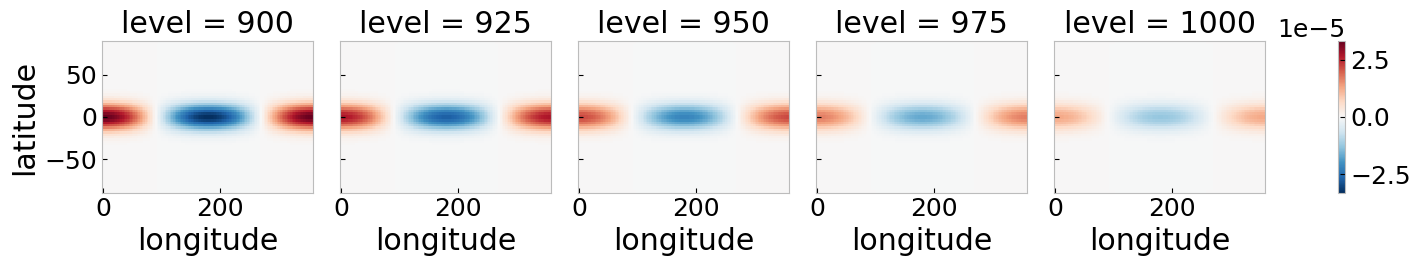

In [107]:
# perturbation_moisture = np.zeros_like(inputs['specific_humidity'])
# n_lev, n_lon, n_lat = np.shape(perturbation_moisture)

# perturbation_moisture = np.sin(n_lon/180)[np.newaxis, :, np.newaxis]*np.exp(-(n_lat/20000)**2)[np.newaxis, np.newaxis, :]



In [115]:
np.any(np.isnan(moisture_perturbation))

<xarray.DataArray ()> Size: 1B
array(False)

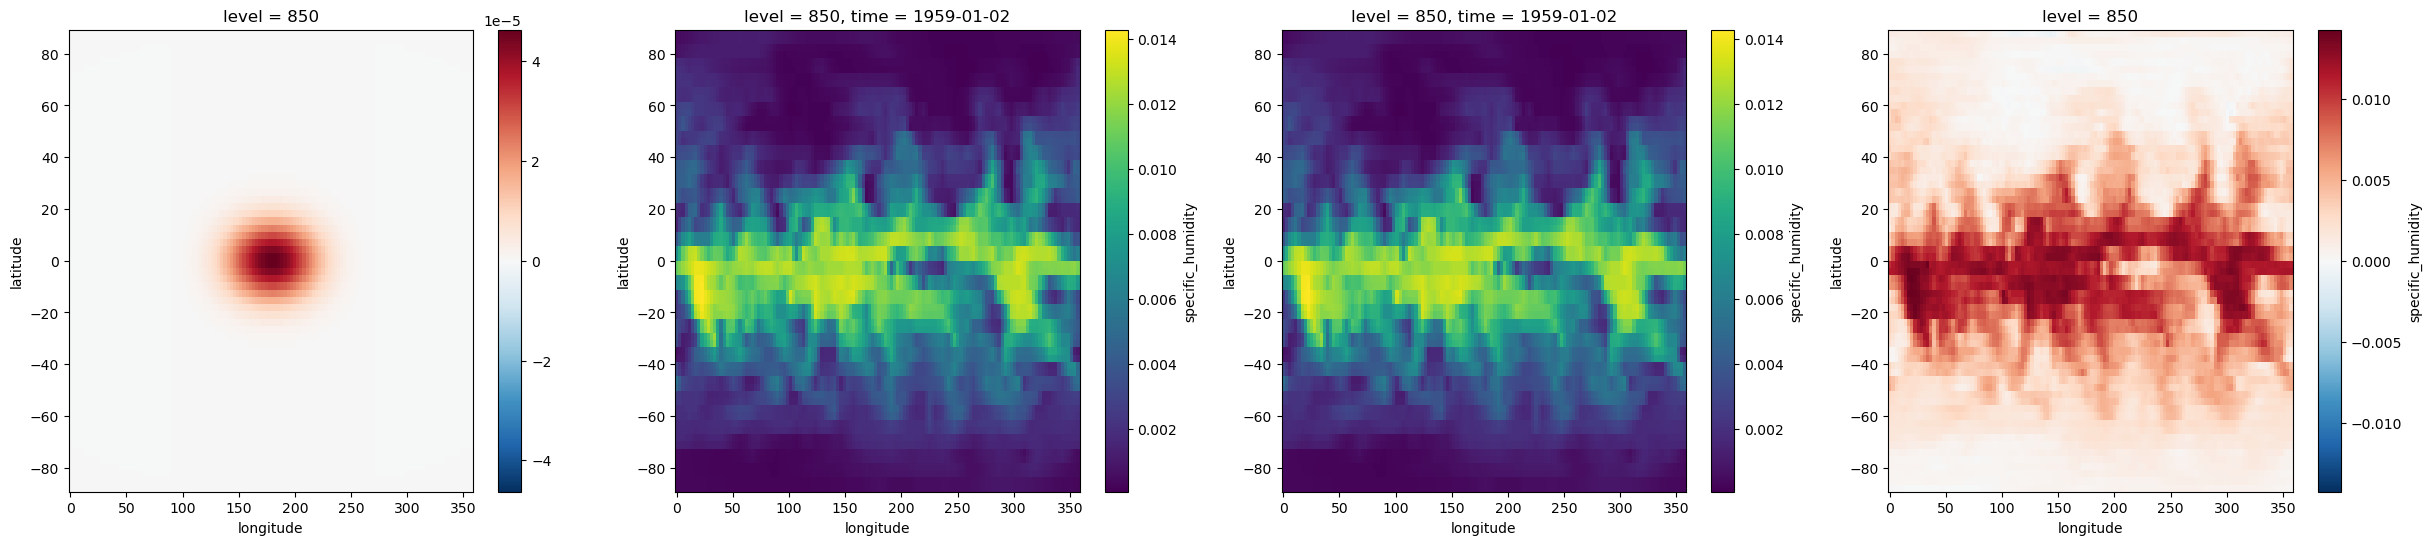

In [12]:
moisture_field = data['specific_humidity'].isel(time=0, drop=True)
moisture_perturbation = (
    moisture_field.mean(dim=['latitude', 'longitude'])
    * np.exp(-(moisture_field.level/400)**2)
    * np.cos(2*(moisture_field.longitude-180)*(np.pi/360))
    * np.exp(-60*((moisture_field.longitude-180)/360)**2)
    * np.exp(-(moisture_field.latitude/15)**2)
)

ds = neuralgcm.demo.load_data(model.data_coords)
ds_init = ds.isel(time=0)
new_ds_init = ds_init.copy(deep=True)
new_ds_init['specific_humidity'][:] += moisture_perturbation.values

perturbation, perturbation_forcings = model.data_from_xarray(new_ds_init)
encoded_perturbation = model.encode(perturbation, forcings, jax.random.key(42))

# perturbation_state = encoded.replace(state = encoded_perturbation.state - encoded.state)
decoded_perturbation = model.data_to_xarray(model.decode(encoded_perturbation, forcings), times=None)

[fig, ax] = plt.subplots(1, 4, figsize=(30,6))
moisture_perturbation.sel(level=850).plot(y='latitude', ax=ax[0])
ds_init['specific_humidity'].sel(level=850).plot(y='latitude', ax=ax[1])
new_ds_init['specific_humidity'].sel(level=850).plot(y='latitude', ax=ax[2])
decoded_perturbation['specific_humidity'].sel(level=850).plot(y='latitude', ax=ax[3])

In [6]:
unrolled, predictions = model.unroll(
    encoded,
    all_forcings,
    steps=outer_steps,
    timedelta=timedelta,
    start_with_input=True
)

In [12]:
decoded_test = model.data_to_xarray(model.decode(advanced, forcings), times=None)
decoded_test

model.data_to_xarray(

<xarray.Dataset> Size: 8MB
Dimensions:                              (level: 37, longitude: 128,
                                          latitude: 64)
Coordinates:
  * longitude                            (longitude) float64 1kB 0.0 ... 357.2
  * latitude                             (latitude) float64 512B -87.86 ... 8...
  * level                                (level) int64 296B 1 2 3 ... 975 1000
Data variables:
    sim_time                             float32 4B ...
    u_component_of_wind                  (level, longitude, latitude) float32 1MB ...
    v_component_of_wind                  (level, longitude, latitude) float32 1MB ...
    specific_cloud_ice_water_content     (level, longitude, latitude) float32 1MB ...
    geopotential                         (level, longitude, latitude) float32 1MB ...
    temperature                          (level, longitude, latitude) float32 1MB ...
    specific_cloud_liquid_water_content  (level, longitude, latitude) float32 1MB ...
    specific_humidity                    (level, longitude, latitude) float32 1MB ...
Attributes:
    longitude_wavenumbers:     64
    total_wavenumbers:         65
    longitude_nodes:           128
    latitude_nodes:            64
    latitude_spacing:          gauss
    longitude_offset:          0.0
    radius:                    1.0
    spherical_harmonics_impl:  RealSphericalHarmonics
    spmd_mesh:                 
    centers:                   [1, 2, 3, 5, 7, 10, 20, 30, 50, 70, 100, 125, ...
    horizontal_grid_type:      Grid
    vertical_grid_type:        PressureCoordinates

In [106]:
advanced_test = advanced.replace(
    state = advanced.state.replace(
        **{
            'sim_time': encoded.state.sim_time,
            'vorticity': encoded.state.vorticity,
        }
    )
)
print(encoded.state.sim_time)
print(advanced.state.sim_time)
print(advanced_test.state.sim_time)

print(np.max(encoded.state.vorticity))
print(np.max(advanced.state.vorticity))
print(np.max(advanced_test.state.vorticity))

-92034.61
-92034.08
-92034.61
0.1488832
0.14624064
0.1488832


In [96]:
# key = jax.random.PRNGKey(0)
random_key = 37
rng_key = jax.random.key(random_key)
noise = jax.random.normal(rng_key, shape=correction.state.vorticity.shape) * 10e-6
# test_correction = correction.replace(state=correction.state.replace(vorticity = jax.numpy.zeros_like(correction.state.vorticity)))
test_correction = correction.replace(state=correction.state.replace(vorticity = correction.state.vorticity + noise))
test_correction = test_correction.replace(state=test_correction.state.replace(divergence = test_correction.state.divergence + noise))
# test_correction = correction.replace(state=correction.state.replace(temperature_variation = correction.state.temperature_variation + noise))

print(correction.state.vorticity[np.unravel_index(np.argmax(test_diff.state.vorticity), np.shape(test_diff.state.vorticity))])
print(test_correction.state.vorticity[np.unravel_index(np.argmax(test_diff.state.vorticity), np.shape(test_diff.state.vorticity))])

-0.033974603
-0.033981882


In [100]:
test_state = advanced.state - encoded.state
new_test_state = test_state.replace(vorticity = test_state.vorticity + noise)
print(np.max(test_state.vorticity))
print(np.max(new_test_state.vorticity))

0.09526889
0.0952808


In [77]:
# import treescope
# treescope.display(test_diff)
np.argmax(test_diff.state.vorticity)
np.shape(test_diff.state.vorticity)
# type(advanced.state.sim_time)
# print(model.sim_time_to_datetime64(encoded.memory.sim_time))
# print(model.sim_time_to_datetime64(unrolled.memory.sim_time))
# print(model.sim_time_to_datetime64(advanced.memory.sim_time))

# advanced = advanced.state.replace(sim_time = encoded.state.sim_time)
# print(model.sim_time_to_datetime64(advanced.state.sim_time))
print(encoded.state.vorticity[np.unravel_index(np.argmax(test_diff.state.vorticity), np.shape(test_diff.state.vorticity))])
print(advanced.state.vorticity[np.unravel_index(np.argmax(test_diff.state.vorticity), np.shape(test_diff.state.vorticity))])
print(correction.state.vorticity[np.unravel_index(np.argmax(test_diff.state.vorticity), np.shape(test_diff.state.vorticity))])
print(new_initial.state.vorticity[np.unravel_index(np.argmax(test_diff.state.vorticity), np.shape(test_diff.state.vorticity))])
print(test_diff.state.vorticity[np.unravel_index(np.argmax(test_diff.state.vorticity), np.shape(test_diff.state.vorticity))])
print(test_diff2.state.vorticity[np.unravel_index(np.argmax(test_diff.state.vorticity), np.shape(test_diff.state.vorticity))])

print(np.unravel_index(np.argmax(test_diff.state.vorticity), np.shape(test_diff.state.vorticity)))
print(np.unravel_index(np.argmax(test_diff2.state.vorticity), np.shape(test_diff2.state.vorticity)))

0.040652502
0.0066778976
-0.033974603
0.0406525
3.7252903e-09
0.0
(7, 0, 56)
(0, 0, 54)


In [39]:
treescope.display(encoded)

In [11]:
# inner_steps = 24  # save model outputs once every 24 hours
# outer_steps = 1 * 24 // inner_steps  # total of 4 days
# timedelta = np.timedelta64(1, 'h') * inner_steps
# times = (np.arange(outer_steps) * inner_steps)  # time axis in hours

# # initialize model state
# inputs = model.inputs_from_xarray(test.isel(time=0))
# input_forcings = model.forcings_from_xarray(test.isel(time=0))
# rng_key = jax.random.key(42)  # optional for deterministic models
# initial_state = model.encode(inputs, input_forcings, rng_key)

# use persistence for forcing variables (SST and sea ice cover)
all_forcings = model.forcings_from_xarray(mean_data.isel(time=0, drop=True).expand_dims(time=[pd.Timestamp('2000-01-15')]).head(time=1))

# # make forecast
# final_state, predictions = model.unroll(
#     initial_state,
#     all_forcings,
#     steps=outer_steps,
#     timedelta=timedelta,
#     start_with_input=True,
# )
# make forecast
advanced_state = model.advance(
    initial_state,
    all_forcings,
    # steps=outer_steps,
    # timedelta=timedelta,
    # start_with_input=True,
)
# predictions_ds = model.data_to_xarray(predictions, times=eval_era5.isel(time=[0]).time+np.timedelta64(1, 'D'))

ValueError: xp and fp must be one-dimensional arrays of equal size

# Mean-state correction

In [8]:
initial_state_ds = eval_era5.isel(time=0)
aligned_initial_state, aligned_predictions = xr.align(initial_state_ds, predictions_ds, join='override')
mean_state_correction = aligned_predictions - aligned_initial_state
corrected_inputs = model.inputs_from_xarray((aligned_predictions - mean_state_correction).isel(time=0))
# corrected_initial_state = model.encode(corrected_inputs, input_forcings, rng_key)

In [2]:
# new_predictions_list = []
# new_predictions_list.append(aligned_predictions)
# for day in range(1, 2, 1):

#     time_start = time.time()
#     previous_state = new_predictions_ds[-1]
#     aligned_previous_state, aligned_mean_state_correction = xr.align(previous_state, mean_state_correction, join='override')
#     corrected_inputs = model.inputs_from_xarray((aligned_previous_state - aligned_mean_state_correction).isel(time=0))
#     corrected_initial_state = model.encode(corrected_inputs, input_forcings, rng_key)

#     time_run = time.time()
#     print(f"Initialization:   {(time_run - time_start):0.2f}s")
#     # make forecast
#     new_final_state, new_predictions = model.unroll(
#         corrected_initial_state,
#         all_forcings,
#         steps=outer_steps,
#         timedelta=timedelta,
#         start_with_input=True,
#     )
#     # print("?")
#     time_append = time.time()
#     print(f"Run Time:         {(time_append - time_run):0.2f}s")
#     new_predictions_list.append(model.data_to_xarray(new_predictions, times=predictions_ds.isel(time=[-1]).time+np.timedelta64(day, 'D')))
#     # new_predictions_list.append(model.data_to_xarray(new_predictions, times=None))
#     time_finish = time.time()
#     print(f"Appending Time:   {(time_finish - time_append):0.2f}s")
#     print(f"Total Loop Time:  {(time_finish - time_start):0.2f}s")

In [121]:

# [aligned_previous_state, aligned_mean_state_correction, aligned_initial_state] = xr.align(*[aligned_previous_state, aligned_mean_state_correction, aligned_initial_state], join='override')
aligned_previous_state - aligned_mean_state_correction
# test_corrected_inputs = model.inputs_from_xarray(
#     (aligned_previous_state - aligned_mean_state_correction + 0.01*aligned_initial_state).isel(time=0)
# )
# test_corrected_initial_state = model.encode(test_corrected_inputs, input_forcings, rng_key)

<xarray.Dataset> Size: 18MB
Dimensions:                              (time: 1, longitude: 187,
                                          latitude: 92, level: 37)
Coordinates:
  * time                                 (time) datetime64[ns] 8B 2018-01-03
  * longitude                            (longitude) float64 1kB 0.0 ... 358.6
  * latitude                             (latitude) float64 736B -88.93 ... 8...
  * level                                (level) int64 296B 1 2 3 ... 975 1000
Data variables:
    v_component_of_wind                  (time, level, longitude, latitude) float32 3MB ...
    temperature                          (time, level, longitude, latitude) float32 3MB ...
    u_component_of_wind                  (time, level, longitude, latitude) float32 3MB ...
    geopotential                         (time, level, longitude, latitude) float32 3MB ...
    specific_humidity                    (time, level, longitude, latitude) float32 3MB ...
    specific_cloud_ice_water_content     (time, level, longitude, latitude) float32 3MB ...
    specific_cloud_liquid_water_content  (time, level, longitude, latitude) float32 3MB ...

In [118]:
# aligned_previous_state - aligned_mean_state_correction + 0.01*aligned_initial_state

<xarray.Dataset> Size: 18MB
Dimensions:                              (time: 1, longitude: 187,
                                          latitude: 92, level: 37)
Coordinates:
  * time                                 (time) datetime64[ns] 8B 2018-01-03
  * longitude                            (longitude) float64 1kB 0.0 ... 358.6
  * latitude                             (latitude) float64 736B -88.93 ... 8...
  * level                                (level) int64 296B 1 2 3 ... 975 1000
Data variables:
    v_component_of_wind                  (time, level, longitude, latitude) float32 3MB ...
    temperature                          (time, level, longitude, latitude) float32 3MB ...
    u_component_of_wind                  (time, level, longitude, latitude) float32 3MB ...
    geopotential                         (time, level, longitude, latitude) float32 3MB ...
    specific_humidity                    (time, level, longitude, latitude) float32 3MB ...
    specific_cloud_ice_water_content     (time, level, longitude, latitude) float32 3MB ...
    specific_cloud_liquid_water_content  (time, level, longitude, latitude) float32 3MB ...

In [29]:
import json

with open(f"{data_directory}/{experiment_to_load}/experiment_parameters.json") as json_file:
    experiment_parameters = json.load(json_file)
    print(experiment_parameters)

int(experiment_parameters['timedelta'].split(" ")[0])

{'experiment_name': 'model_advance_test_1', 'description': 'This test uses the 2.8 deg model and 1-hr timesteps along with the model.advance function', 'model_name': '../neuralgcm/neuralgcm/checkpoints/deterministic_2_8_deg.pkl', 'demo_start_time': '2000-01-15', 'inner_steps': 1, 'outer_steps': 1, 'timedelta': '1 hours', 'n_days': 24, 'random_key': 37, 'noise_amplitude': '1e-14'}


1

In [31]:
np.timedelta64(1, 'h')

numpy.timedelta64(1,'h')

# Analyze data

In [3]:
str_width = 40
savefig = False
reload_data = True
# experiment_to_load = "timedelta_test_2_20250828_1237"
# experiment_to_load = "timedelta_test_3_20250828_1314"
# experiment_to_load = "timedelta_test_4_20250828_1321"
# experiment_to_load = "climatology_test_1_20250829_1447"
# experiment_to_load = "climatology_test_2_20250829_1503"
# experiment_to_load = "model_resolution_test_1_20250903_1306"
# experiment_to_load = "model_resolution_test_2_20250903_1320"
# experiment_to_load = "memory_replacement_test_1_20250903_1415"
# experiment_to_load = "correction_noise_test_1_20250903_1748"
# experiment_to_load = "correction_noise_test_3_20250903_1802"
# experiment_to_load = "correction_noise_test_4_20250903_1813"
experiment_to_load = "correction_noise_test_5_20250904_1156"
# experiment_to_load = "model_advance_test_1_20250904_1232"
# experiment_to_load = "model_advance_test_2_20250904_1255"
# experiment_to_load = "model_advance_test_3_20250904_1301"
# experiment_to_load = "perturbation_test_1_20250909_1606"
# experiment_to_load = "stochastic_model_test_1_20250923_1838"

if 'data' not in locals() or reload_data:
    data = xr.load_dataset(f"{data_directory}/{experiment_to_load}/model_output.nc")

plt.rcParams.update({'font.size':18})
variable_to_plot = 'specific_humidity'
# daily_data = data[variable_to_plot]#.groupby(data.time // 24).mean(dim='time')
# p = (
#     1000*daily_data.sel(level=850)
#     # - daily_data.sel(level=850).mean(dim=['latitude', 'longitude'])
#     - 1000*daily_data.sel(level=850).isel(time=0)
# ).plot(
#     figsize=(16,len(daily_data.time)/4),
#     x='longitude',
#     y='latitude',
#     col='time',
#     col_wrap=6,
#     # levels=np.linspace(-2e3, 2e3, 21),
#     levels = np.linspace(-3, 3, 21),
#     # levels = 21,
#     extend='both',
#     cbar_kwargs={"shrink": 0.75, 'label': 'Specific Humidity (g/kg)'},
# )
daily_data = data[variable_to_plot]#.groupby(data.time // 24).mean(dim='time')
# p = (
#     100*(daily_data.sel(level=850) - daily_data.sel(level=850).isel(time=0))/(daily_data.sel(level=850).isel(time=0))
# ).plot(
#     figsize=(24,1.5*len(daily_data.time)/4),
#     x='longitude',
#     y='latitude',
#     col='time',
#     col_wrap=8,
#     # levels=np.linspace(-2e3, 2e3, 21),
#     # levels = np.linspace(-3, 3, 21),
#     levels = np.linspace(-100, 100, 21),
#     # levels = 21,
#     extend='both',
#     cbar_kwargs={"shrink": 0.75, 'label': '% diff'},
# )
# p.fig.suptitle(f"{variable_to_plot.replace("_", " ").title()}; Difference from Timestep 0", x=0.45, y=1.025)

# output_filename = '30_year_climatology_initial_condition_run'
# print(f"Output directory: {neuralGCM_output_directory}/")
# print(f"Output filename: {output_filename}")
# if savefig:
#     print(f"{f'Saving...':<{str_width-1}}", end="")
#     plt.savefig(
#         f"{neuralGCM_output_directory}/{output_filename}.png",
#         dpi=500,
#         bbox_inches="tight",
#     )
#     print(rf"{'✔':>1}")
# else:
#     print("Not Saving")
#     plt.show()

In [2]:
def gaussian_lat_smooth(std_data, lat, sigma_deg=5):
    sigma = np.radians(sigma_deg)
    lat_rad = np.radians(lat)

    if std_data.ndim == 3:
        smoothed = np.zeros_like(std_data)
        for j in range(len(lat)):
            dlat = lat_rad - lat_rad[j]
            weights = np.exp(-0.5 * (dlat / sigma)**2)
            weights /= weights.sum()
            smoothed[:, :, j] = np.sum(std_data * weights[None, None, :], axis=-1)
    elif std_data.ndim == 2:
        smoothed = np.zeros_like(std_data)
        for j in range(len(lat)):
            dlat = lat_rad - lat_rad[j]
            weights = np.exp(-0.5 * (dlat / sigma)**2)
            weights /= weights.sum()
            smoothed[:, j] = np.sum(std_data * weights[None, :], axis=-1)
    else:
        raise ValueError("Data is not 2D or 3D")
    return smoothed

In [146]:
def gaussian_lat_smooth(std_data: xr.DataArray, sigma_deg: float = 5):
    """
    Apply Gaussian smoothing along the latitude dimension using a given sigma (in degrees).
    Works for 2D or 3D DataArrays with a 'lat' coordinate.
    """

    if "latitude" not in std_data.dims:
        raise ValueError("Input data must have a 'lat' dimension")

    # Convert to radians
    lat = std_data.latitude.values
    lat_rad = np.radians(lat)
    sigma = np.radians(sigma_deg)

    # Construct pairwise Gaussian weights between all latitudes
    dlat = lat_rad - lat_rad[:, None]  # shape: (nlat, nlat)
    weights = np.exp(-0.5 * (dlat / sigma) ** 2)
    weights /= weights.sum(axis=1, keepdims=True)

    # Wrap as xarray DataArray for broadcasting and alignment
    w = xr.DataArray(weights, coords={"latitude": lat, "lat_out": lat}, dims=("lat_out", "latitude"))

    # Perform weighted sum along latitude
    smoothed = (std_data * w).sum(dim="latitude") / w.sum(dim="latitude")

    # Rename lat_out → lat for consistency
    smoothed = smoothed.rename({"lat_out": "latitude"})

    # Copy attributes and name
    # smoothed.attrs = std_data.attrs
    # smoothed.name = std_data.name

    return smoothed

In [187]:
test_data = xr.zeros_like(ds[[var for var in pl_vars]]).expand_dims({'member':Nens0}, axis=0).copy(deep=True)
for v in pl_vars:
    test_data[v][:] = rng.normal(0, 1, (Nens0, Nlevels, len(lon), len(lat)))
# test_data['specific_humidity'][:].shape

In [207]:
test_perturbed = ds[[var for var in pl_vars]] + test_data * (pert_scale * test_smooth)
test_perturbed

<xarray.Dataset> Size: 2GB
Dimensions:                              (longitude: 128, latitude: 64,
                                          level: 37, member: 100)
Coordinates:
  * longitude                            (longitude) float64 1kB 0.0 ... 357.2
  * latitude                             (latitude) float64 512B -87.86 ... 8...
  * level                                (level) int64 296B 1 2 3 ... 975 1000
Dimensions without coordinates: member
Data variables:
    u_component_of_wind                  (level, longitude, latitude, member) float64 242MB ...
    specific_cloud_ice_water_content     (level, longitude, latitude, member) float64 242MB ...
    geopotential                         (level, longitude, latitude, member) float64 242MB ...
    specific_humidity                    (level, longitude, latitude, member) float64 242MB ...
    v_component_of_wind                  (level, longitude, latitude, member) float64 242MB ...
    specific_cloud_liquid_water_content  (level, longitude, latitude, member) float64 242MB ...
    temperature                          (level, longitude, latitude, member) float64 242MB ...

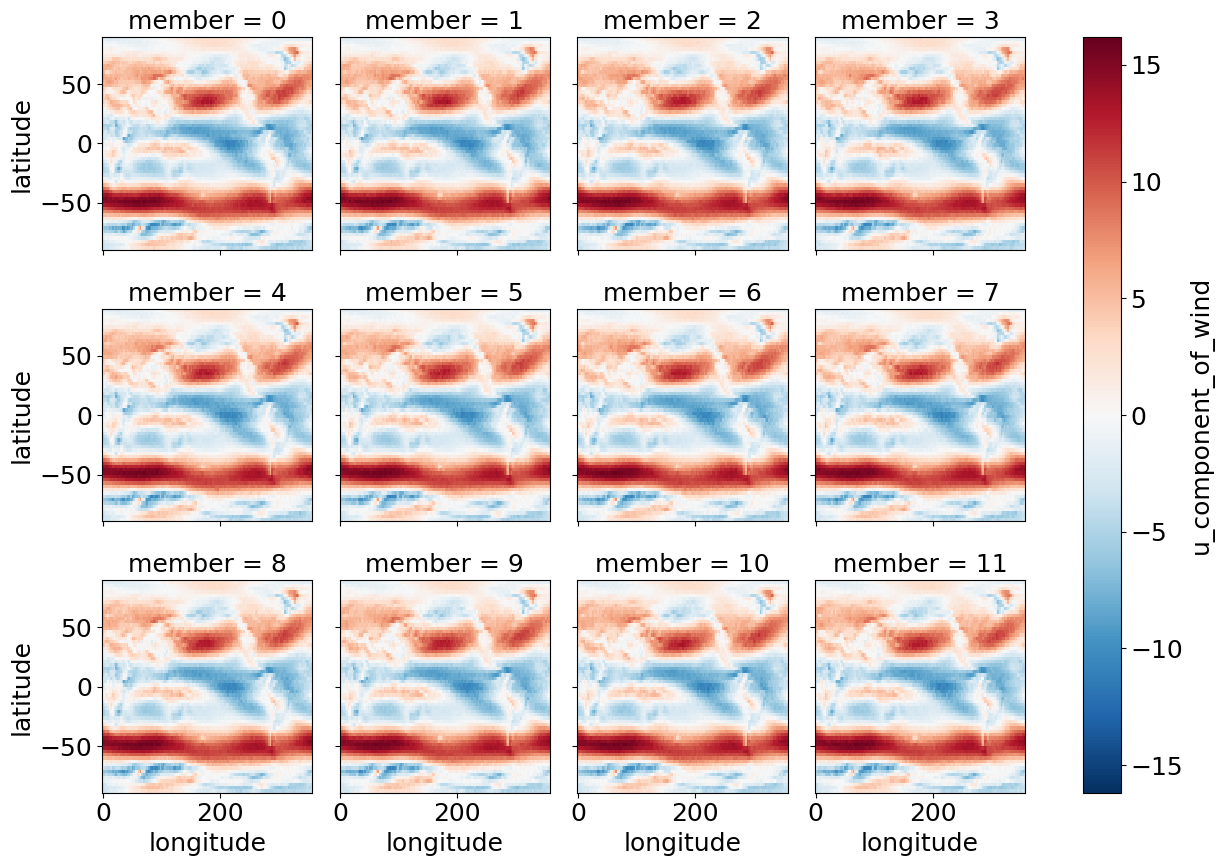

In [210]:
(test_perturbed['u_component_of_wind'].sel(level=850, member=slice(0,12))).plot(x='longitude', col='member', col_wrap=4)

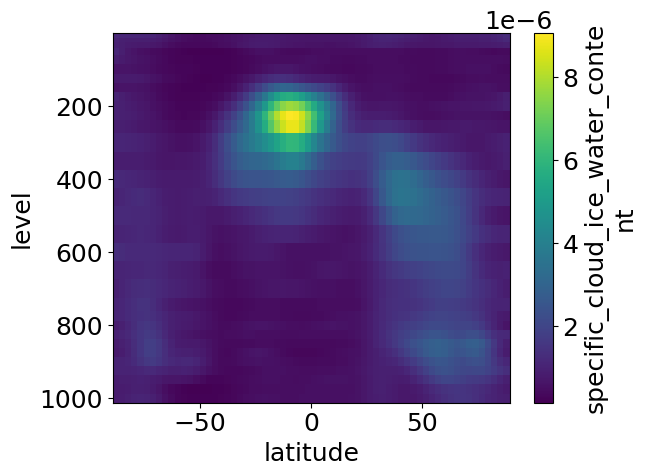

In [159]:
test_smooth = gaussian_lat_smooth(ds.std(dim='longitude', ddof=1))
# test_smooth['specific_humidity'].plot(y='level')
# plt.gca().invert_yaxis()
test_smooth['specific_cloud_ice_water_content'].plot(y='level')
plt.gca().invert_yaxis()

In [72]:
# Convert to radians
lat = ds.latitude.values
lat_rad = np.radians(lat)
sigma = np.radians(5)

dlat = lat_rad - lat_rad[:, None]  # shape: (nlat, nlat)
weights = np.exp(-0.5 * (dlat / sigma) ** 2)
weights /= weights.sum(axis=1, keepdims=True)

weights.shape

(64, 64)

In [78]:
pert_scale = 1e-1
Nens0 = 100   # make Nens0 perturbations
Nens = 10     # ones that will be actually used
seed_base = 42

## initial condition (neuralGCM format)
ds = data.isel(time=0)
lat = ds.latitude.values
lon = ds.longitude.values
lev = ds.level.values

pl_vars = [v for v in ds.data_vars if 'level' in ds[v].dims]
sfc_vars = [v for v in ds.data_vars if 'level' not in ds[v].dims]

control_pl = np.stack([ds[v].values for v in pl_vars])  # (Nvars, level, lon, lat)
control_sfc = np.stack([ds[v].values for v in sfc_vars])  # (Nvars, lon, lat)

## smoothed standard deviation of each variables f(level, lat)
pl_latstd = np.std(control_pl, axis=2, ddof=1)  # (Nvars, level, lat)
pl_latstd_smooth = gaussian_lat_smooth(pl_latstd, lat, sigma_deg=5)


seed_base = 42
rng = np.random.default_rng(seed_base)
Nvars_pl, Nlevels = control_pl.shape[:2]
rand_pl_all = rng.normal(0, 1, (Nens0, Nvars_pl, Nlevels, len(lon), len(lat)))

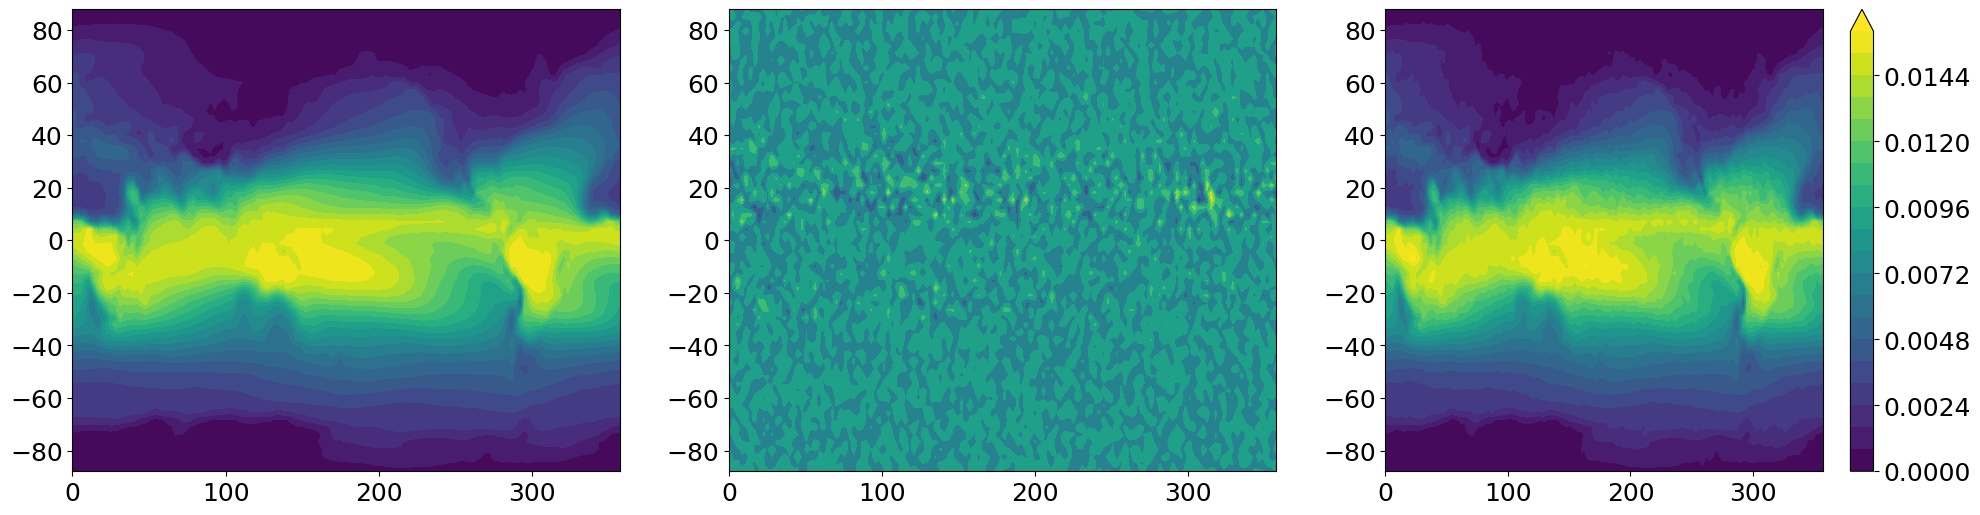

In [114]:
indices = np.arange(0, Nens0, Nens0 // Nens)

pert_pl = rand_pl_all[4] * (pert_scale * pl_latstd_smooth[:, :, None, :])
[fig, ax] = plt.subplots(1, 3, figsize=(24,6))
im = ax[0].contourf(lon, lat, control_pl[3, -4].T, levels=np.linspace(0, 0.016, 21), extend='max')
ax[1].contourf(lon, lat, pert_pl[3, -4].T)
im = ax[2].contourf(lon, lat, (control_pl + pert_pl)[3, -4].T, levels=im.levels, extend='max')
plt.colorbar(im)

In [133]:
ds = data.isel(time=0)


<xarray.Dataset> Size: 8MB
Dimensions:                              (level: 37, longitude: 128,
                                          latitude: 64)
Coordinates:
  * longitude                            (longitude) float64 1kB 0.0 ... 357.2
  * latitude                             (latitude) float64 512B -87.86 ... 8...
  * level                                (level) int64 296B 1 2 3 ... 975 1000
Data variables:
    u_component_of_wind                  (level, longitude, latitude) float32 1MB ...
    sim_time                             float32 4B 9.682e+04
    specific_cloud_ice_water_content     (level, longitude, latitude) float32 1MB ...
    geopotential                         (level, longitude, latitude) float32 1MB ...
    specific_humidity                    (level, longitude, latitude) float32 1MB ...
    v_component_of_wind                  (level, longitude, latitude) float32 1MB ...
    specific_cloud_liquid_water_content  (level, longitude, latitude) float32 1MB ...
    temperature                          (level, longitude, latitude) float32 1MB ...
Attributes:
    longitude_wavenumbers:     64
    total_wavenumbers:         65
    longitude_nodes:           128
    latitude_nodes:            64
    latitude_spacing:          gauss
    longitude_offset:          0.0
    radius:                    1.0
    spherical_harmonics_impl:  RealSphericalHarmonics
    spmd_mesh:                 
    centers:                   [   1    2    3    5    7   10   20   30   50 ...
    horizontal_grid_type:      Grid
    vertical_grid_type:        PressureCoordinates

In [12]:
ds = data.isel(time=0)
lat = ds.latitude.values
lon = ds.longitude.values
lev = ds.level.values

pl_vars = [v for v in ds.data_vars if 'level' in ds[v].dims]
sfc_vars = [v for v in ds.data_vars if 'level' not in ds[v].dims]

control_pl = np.stack([ds[v].values for v in pl_vars])  # (Nvars, level, lon, lat)
control_sfc = np.stack([ds[v].values for v in sfc_vars])  # (Nvars, lon, lat)

pl_latstd = np.std(control_pl, axis=2, ddof=1)  # (Nvars, level, lat)
pl_latstd_smooth = gaussian_lat_smooth(pl_latstd, lat, sigma_deg=5)

In [24]:
print(f"{lat.shape=}, {lon.shape=}, {lev.shape=}")

lat.shape=(64,), lon.shape=(128,), lev.shape=(37,)


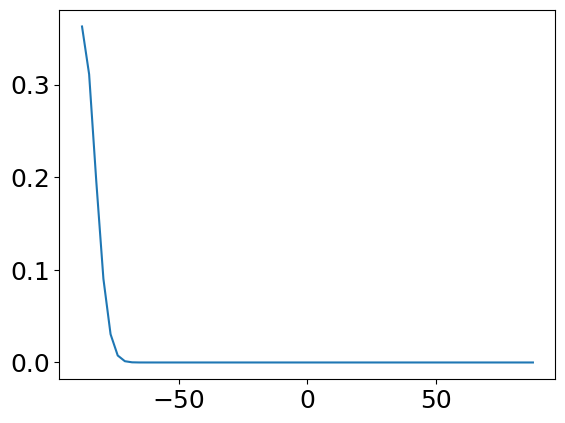

In [59]:
plt.plot(lat, (np.exp(-0.5 * ((lat_rad - lat_rad[0])/np.radians(5))**2))/np.sum(np.exp(-0.5 * ((lat_rad - lat_rad[0])/np.radians(5))**2)))

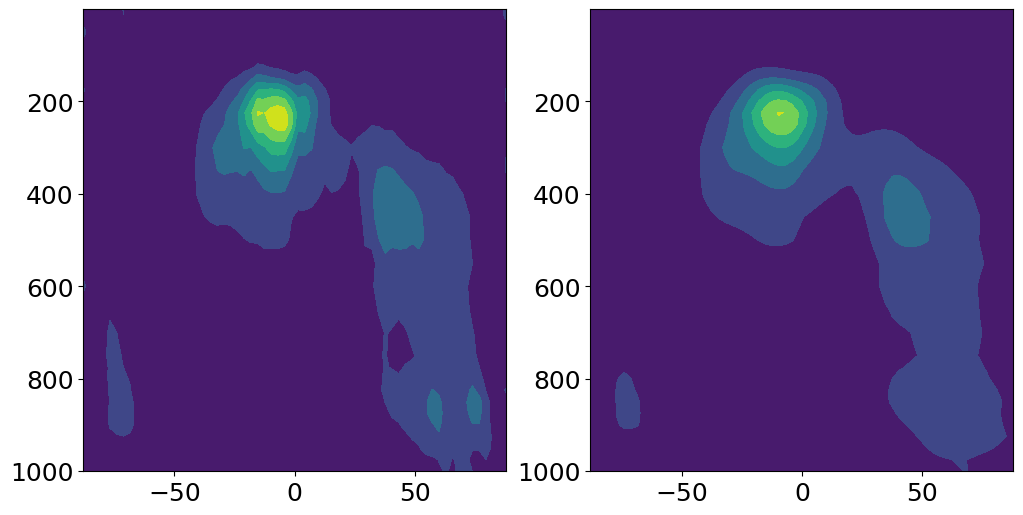

In [50]:
smoothed = np.zeros_like(pl_latstd)
sigma = np.radians(5)
lat_rad = np.radians(lat)
for j in range(len(lat)):
    dlat = lat_rad - lat_rad[j]
    weights = np.exp(-0.5 * (dlat / sigma)**2)
    weights /= weights.sum()
    smoothed[:, :, j] = np.sum(pl_latstd * weights[None, None, :], axis=-1)

[fig, ax] = plt.subplots(1, 2, figsize=(12,6))
ax[0].contourf(
    lat,
    lev,
    pl_latstd[1]
)
ax[0].invert_yaxis()

ax[1].contourf(
    lat,
    lev,
    smoothed[1]
)
ax[1].invert_yaxis()

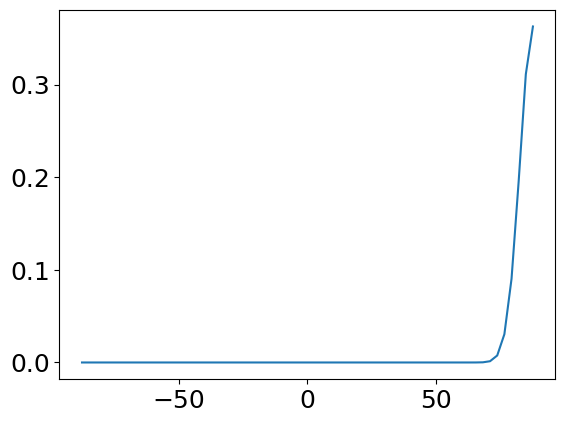

In [44]:
plt.plot(lat, weights)

In [40]:
sigma

array([[[5.88920079e-02, 9.66345146e-02, 1.25536591e-01, ...,
         2.72116065e-01, 2.66786397e-01, 3.47017050e-01],
        [5.82882985e-02, 8.11205357e-02, 9.44317803e-02, ...,
         2.85615414e-01, 2.89278418e-01, 3.29832137e-01],
        [5.49499877e-02, 7.23557174e-02, 6.60410076e-02, ...,
         2.86571622e-01, 2.92822868e-01, 3.03542614e-01],
        ...,
        [4.81029414e-02, 5.88800497e-02, 4.76041585e-02, ...,
         2.74797380e-02, 2.81650573e-02, 3.45503800e-02],
        [4.84440401e-02, 5.79681732e-02, 4.57224213e-02, ...,
         2.98243314e-02, 3.03364713e-02, 3.53647955e-02],
        [4.91377935e-02, 5.69765568e-02, 4.51968201e-02, ...,
         2.90074497e-02, 2.92954892e-02, 3.14487666e-02]],

       [[2.41074201e-08, 1.78421207e-08, 1.88429858e-08, ...,
         1.59471405e-08, 1.48250701e-08, 3.29862644e-08],
        [2.38500508e-08, 1.75644281e-08, 1.89826128e-08, ...,
         1.60989035e-08, 1.49533523e-08, 3.31780399e-08],
        [2.38797675e-08, 

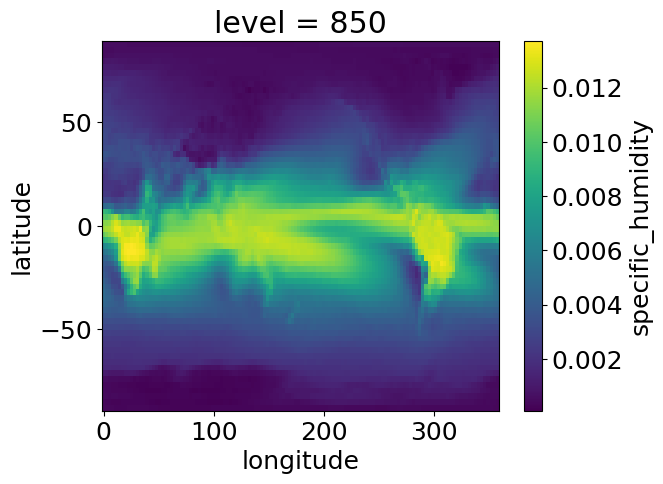

In [4]:
daily_data.isel(time=0).sel(level=850).plot(x='longitude')

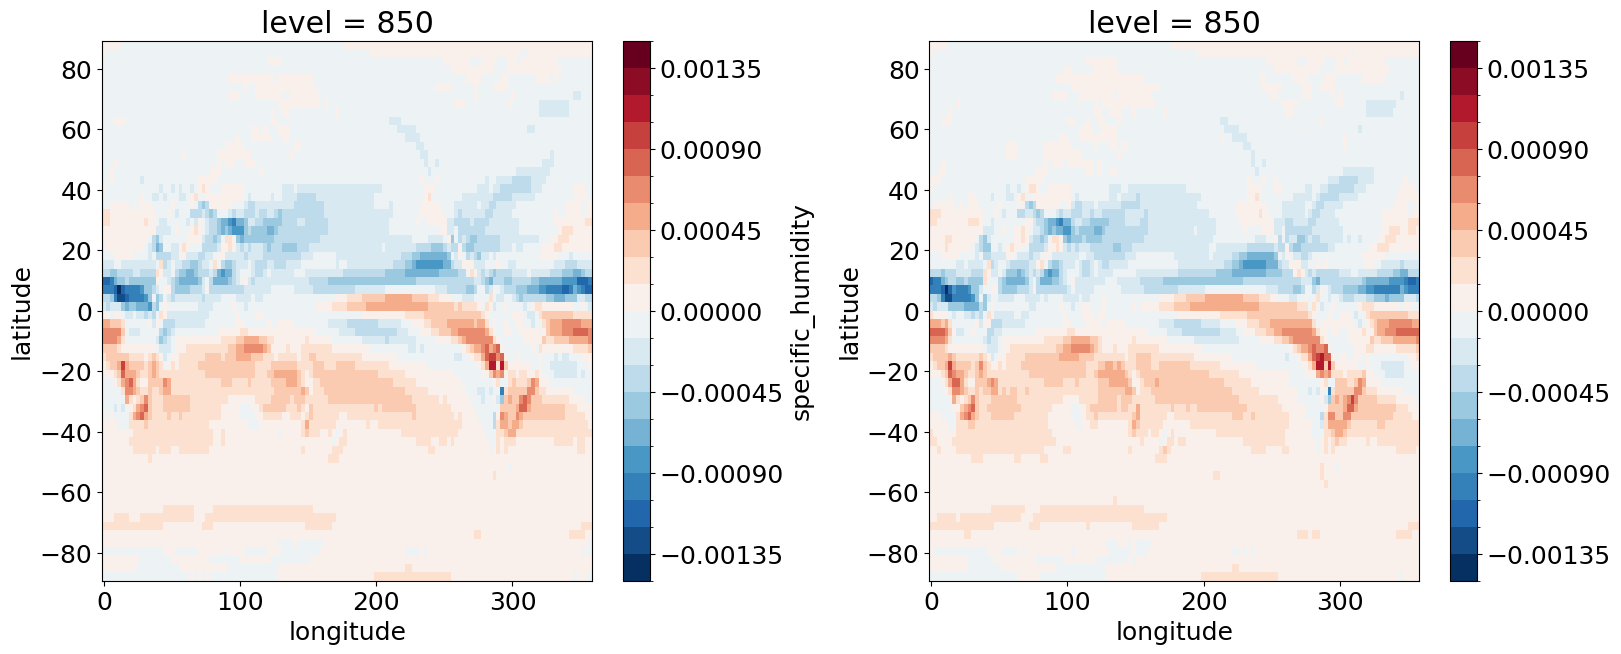

In [77]:
offset = xr.zeros_like(daily_data.latitude)
# offset[:] = -0.025*np.sign(daily_data.latitude)*(daily_data.isel(time=0).sel(level=850).differentiate('latitude')).max()*((90-daily_data.latitude)/90)
offset = 0.025*(daily_data.isel(time=0).sel(level=850).differentiate('latitude')).max()*((90-np.abs(daily_data.latitude))/90)
# offset[32:] = -0.025*(daily_data.isel(time=0).sel(level=850).differentiate('latitude')).max()*np.abs(((90-daily_data.latitude[32:])/90))
offset_gradient = daily_data.differentiate('latitude') + offset
# [fig, ax] = plt.subplots(2, 1, figsize=(12,12))
fig = plt.figure(figsize=(16, 6))
gs = GridSpec(1, 2,figure=fig)
gs.update(top=0.95, bottom=0.05, left=0.05, right=0.95, wspace=0.35)
ax = np.array([fig.add_subplot(gs[i]) for i in range(2)])

daily_data.isel(time=0).sel(level=850).differentiate('latitude').plot(x='longitude', ax=ax[0], levels=np.linspace(-0.0015, 0.0015, 21))
offset_gradient.isel(time=0).sel(level=850).plot(x='longitude', ax=ax[1], levels=np.linspace(-0.0015, 0.0015, 21))

In [79]:
(90-np.abs(daily_data.latitude))/90

<xarray.DataArray 'latitude' (latitude: 64)> Size: 512B
array([0.02373557, 0.05448303, 0.08541208, 0.11638215, 0.14736778,
       0.17836094, 0.20935831, 0.24035827, 0.27135992, 0.30236276,
       0.33336644, 0.36437076, 0.39537556, 0.42638074, 0.45738621,
       0.48839193, 0.51939784, 0.55040391, 0.58141012, 0.61241643,
       0.64342285, 0.67442934, 0.7054359 , 0.73644251, 0.76744917,
       0.79845588, 0.82946261, 0.86046938, 0.89147616, 0.92248296,
       0.95348977, 0.98449659, 0.98449659, 0.95348977, 0.92248296,
       0.89147616, 0.86046938, 0.82946261, 0.79845588, 0.76744917,
       0.73644251, 0.7054359 , 0.67442934, 0.64342285, 0.61241643,
       0.58141012, 0.55040391, 0.51939784, 0.48839193, 0.45738621,
       0.42638074, 0.39537556, 0.36437076, 0.33336644, 0.30236276,
       0.27135992, 0.24035827, 0.20935831, 0.17836094, 0.14736778,
       0.11638215, 0.08541208, 0.05448303, 0.02373557])
Coordinates:
  * latitude  (latitude) float64 512B -87.86 -85.1 -82.31 ... 82.31 85.1 87.86

In [80]:
default_int = xr.zeros_like(offset_gradient)
offset_int = xr.zeros_like(offset_gradient)
for lat_index, lat in enumerate(daily_data.latitude):
    offset_int[..., lat_index] = offset_gradient.sel(latitude=slice(-90, lat)).integrate('latitude')
    default_int[..., lat_index] = daily_data.isel(time=0).sel(level=850).differentiate('latitude').sel(latitude=slice(-90, lat)).integrate('latitude')

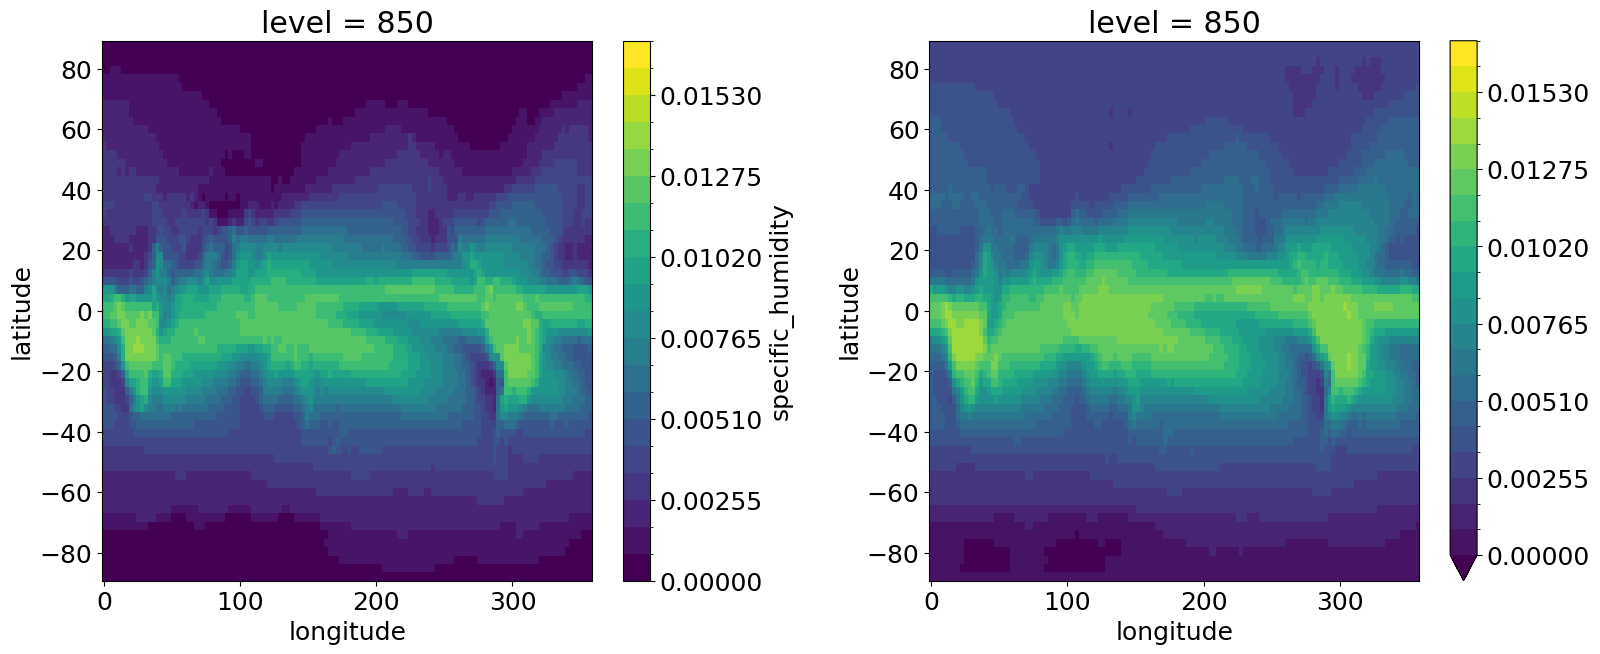

In [81]:
fig = plt.figure(figsize=(16, 6))
gs = GridSpec(1, 2,figure=fig)
gs.update(top=0.95, bottom=0.05, left=0.05, right=0.95, wspace=0.35)
ax = np.array([fig.add_subplot(gs[i]) for i in range(2)])
daily_data.isel(time=0).sel(level=850).plot(x='longitude', ax=ax[0], cmap='viridis', levels=np.linspace(0, 0.017, 21))
offset_int.isel(time=0).sel(level=850).plot(x='longitude', ax=ax[1], cmap='viridis', levels=np.linspace(0, 0.017, 21))

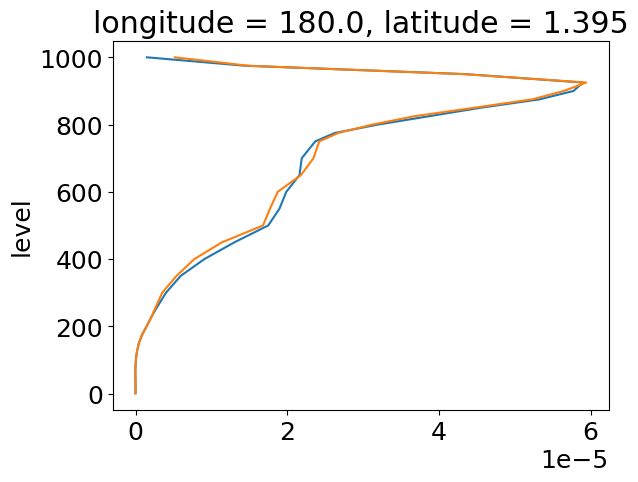

In [55]:
daily_data.isel(time=0).sel(longitude=180, latitude=0, method='nearest').differentiate('level').plot(y='level')
offset_int.isel(time=0).sel(longitude=180, latitude=0, method='nearest').differentiate('level').plot(y='level')

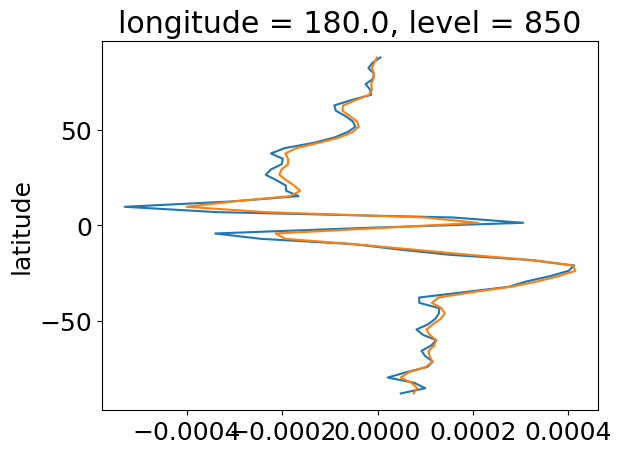

In [82]:
daily_data.isel(time=0).sel(longitude=180, level=850).differentiate('latitude').plot(y='latitude')
offset_int.isel(time=0).sel(longitude=180, level=850).differentiate('latitude').plot(y='latitude')

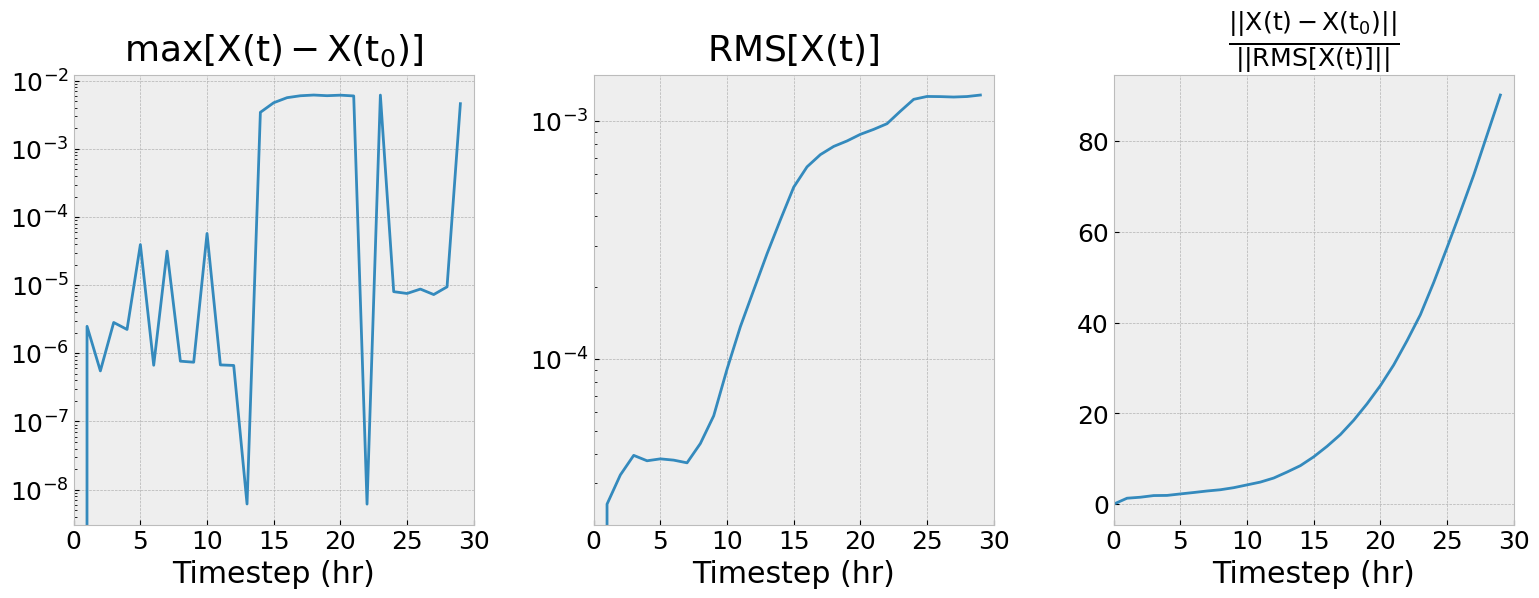

In [29]:
rms = []
ratio_list = []
variable_difference_list = []
variable_rms = []
spatial_integral = []
variable = daily_data
# variable = data['variable']#.isel(time=0, drop=True).rename({'new_dim':'time'})
timesteps_to_plot = len(data.time)
for timestep in np.arange(0, timesteps_to_plot, 1):

    variable_difference = np.abs(variable.isel(time=timestep) - variable.isel(time=0))

    variable_rms.append(np.max(np.abs(np.sqrt(((variable_difference - variable_difference.mean(dim='longitude'))**2).mean(dim='longitude')))))
    rms_deviation = np.sqrt(((variable.isel(time=timestep) - variable.isel(time=timestep).mean(dim='longitude'))**2).mean(dim='longitude'))

    # Peter comment - Compute ratio using integral over latitude and height of both numerator and denomator
    spatial_integral.append(
        variable_difference.integrate('latitude').integrate('level').integrate('longitude')
        / rms_deviation.integrate('latitude').integrate('level')
    )

    ratio = variable_difference/rms_deviation
    [lev_max, lon_max, lat_max] = np.unravel_index(ratio.argmax(), ratio.shape)
    rms.append(rms_deviation[lev_max, lat_max])
    ratio_list.append(ratio[lev_max, lon_max, lat_max])
    variable_difference_list.append(variable_difference[lev_max, lon_max, lat_max])
    # variable_difference_list.append(zonal_mean_difference[lev_max, lat_max])


plt.style.use('bmh')
plt.rcParams.update({'font.size':18})
plt.rcParams["mathtext.default"] = 'regular'

fig = plt.figure(figsize=(16, 5))
gs = GridSpec(1, 3, figure=fig)
gs.update(top=0.95, bottom=0.05, left=0.05, right=0.95, hspace=0.1, wspace=0.3)

axes = []
axes.append(fig.add_subplot(gs[0]))
axes.append(fig.add_subplot(gs[1]))
axes.append(fig.add_subplot(gs[2]))

axes[0].set_title(r"max[$X(t) - X(t_{0})$]", pad=10)
axes[0].plot(variable.time[:timesteps_to_plot], variable_difference_list)
# axes[0].set_ylim(-10, 1500)
# axes[0].set_yticks(np.arange(0, 1500+200, 200))
# axes[0].axhline(y=0, lw=2, ls='-', color='#bcbcbc')
# axes[0].set_ylabel(r'm$^{2}$ s$^{-2}$')
axes[0].set_yscale('log')

axes[1].set_title(r"RMS[$X(t)$]", pad=10)
axes[1].plot(variable.time[:timesteps_to_plot], variable_rms)
# axes[1].set_ylim(-10, 1500)
# axes[1].set_yticks(np.arange(0, 1500+200, 200))
# axes[1].axhline(y=0, lw=2, ls='-', color='#bcbcbc')
# axes[1].set_ylabel(r'm$^{2}$ s$^{-2}$')
axes[1].set_yscale('log')

axes[2].set_title(r"$\frac{||X(t) - X(t_{0})||}{||RMS[X(t)]||}$", pad=10)
axes[2].plot(variable.time[:timesteps_to_plot], spatial_integral)

for ax in axes:
    ax.set_xlim(0, timesteps_to_plot)
    ax.set_xticks(np.arange(0, timesteps_to_plot+5, 5))
    ax.set_xlabel('Timestep (hr)')
plt.show()

In [69]:
difference = (
    data['geopotential'].isel(new_dim=-1)
    - data['geopotential'].isel(new_dim=0)
)
max_location = difference.idxmax(dim='latitude').idxmax(dim='level').idxmax('longitude')

stationary_wave = data['geopotential'].isel(new_dim=0) - data['geopotential'].isel(new_dim=0).mean(dim='longitude')
variance = stationary_wave**2
zonal_mean_std = np.sqrt(variance.mean(dim='longitude'))
difference.sel(*max_location)/max_zonal_mean_std

# (difference/std).sel(level=850).isel(time=0).plot()

# zonal mean of initial state
# subtract that from the whole field
# zonal average of variance


ValueError: the first argument to .sel must be a dictionary

In [70]:
max_location


<xarray.DataArray 'longitude' (time: 1)> Size: 8B
array([146.25])
Coordinates:
  * time     (time) datetime64[ns] 8B 2018-01-01

In [68]:
max_location

<xarray.DataArray 'level' (time: 1, longitude: 256)> Size: 2kB
array([[   1.,    2.,    2.,    7.,  800.,    3.,    2.,    2.,    2.,
         100.,    1.,   10.,    2.,   20.,    3.,  100.,  975.,    7.,
           2.,    1.,   30.,   10.,    1.,  150.,    7.,   10.,    5.,
           3.,    1.,    5.,  825.,  100.,    7.,  450.,    2.,   50.,
           7.,    1.,   50.,   30.,  250.,  975.,    3.,  125.,   30.,
          50.,    3.,    7.,  125.,    2.,   10.,   50.,    7.,   70.,
          20.,    2.,    3.,    5.,    7.,    2.,   10.,   10.,   30.,
           5.,   20.,    7.,    1.,    1.,   20.,  750.,    2.,    7.,
           7.,   50.,  300.,   50.,  825.,    2.,   50.,  550.,   70.,
           2.,   50.,    5.,    7.,   30.,    5.,    5.,    3.,   50.,
         175.,    2.,  925.,    3.,   20.,   10.,    5.,   10.,    1.,
         100.,   30.,    7.,  875.,  650., 1000.,    1.,  550.,   30.,
           3.,  400.,   30.,    3.,   10.,    1.,    5.,    7.,  875.,
         750.,  950.,  175.,    2.,    3.,    1.,   20.,   20.,  200.,
           1.,   50.,    7.,  700.,  825.,  775.,  875.,  350.,    3.,
           7.,  350.,  750.,  775.,    5.,    1.,  950.,    2.,    1.,
         875.,  350.,  775.,  750.,  875.,  100.,  800.,   20.,  925.,
         775.,   10.,  450.,  825.,  800.,   20.,  775.,    2.,  875.,
          50.,    1.,  875.,  875.,  975.,  200.,  700.,    7.,  775.,
          10.,  950.,  775.,  100.,    5.,    5.,  700.,    3.,    7.,
          20.,  750.,    5.,  775.,  825.,  900.,   50.,  850.,   20.,
           7.,  700.,    5.,   30.,  775.,  800.,    5.,  600.,  925.,
          50.,  825.,    7.,  825.,  150.,    2.,  775.,   30.,  800.,
          20.,  800.,    7.,  875.,  875.,  200.,  950.,   10.,    2.,
         200.,  800.,    7.,  125.,   50.,    5.,  650.,   50., 1000.,
          20.,  200.,    5.,   30.,  175.,    3.,   50.,    3.,    3.,
         200.,    1.,  850.,  750.,    5.,  775.,    3.,   50.,  600.,
         400.,    7.,    7.,    1.,   20.,  775.,   10.,   30.,    5.,
           7.,    5.,  900.,   10.]])
Coordinates:
  * longitude  (longitude) float64 2kB 0.0 1.406 2.812 ... 355.8 357.2 358.6
  * time       (time) datetime64[ns] 8B 2018-01-01

In [63]:
max_location = difference.idxmax(dim='latitude').idxmax(dim='level')
zonal_mean_std

<xarray.DataArray 'geopotential' (time: 1, level: 37, latitude: 128)> Size: 19kB
array([[[1515.9637  , 2639.3142  , 4391.0576  , ...,  659.5235  ,
          363.72476 ,  292.13925 ],
        [1079.8546  , 1802.8202  , 3867.4604  , ...,  805.3678  ,
          479.72968 ,  161.77647 ],
        [1062.2272  , 2524.728   , 4134.1626  , ...,  752.9944  ,
          600.8447  ,  181.37874 ],
        ...,
        [ 176.40309 ,  295.46008 ,  344.47864 , ...,  144.00269 ,
           93.03391 ,   39.176483],
        [ 176.67859 ,  294.55618 ,  336.43042 , ...,  146.30246 ,
           97.72469 ,   43.350124],
        [ 176.79004 ,  292.62473 ,  329.24844 , ...,  152.51068 ,
          104.62877 ,   45.79862 ]]], dtype=float32)
Coordinates:
  * latitude  (latitude) float64 1kB -88.93 -87.54 -86.14 ... 86.14 87.54 88.93
  * level     (level) int32 148B 1 2 3 5 7 10 20 ... 875 900 925 950 975 1000
  * time      (time) datetime64[ns] 8B 2018-01-01

In [36]:
percent_error = 100*(data['geopotential'].isel(new_dim=0) - data['geopotential'].isel(new_dim=-1))/(data['geopotential'].isel(new_dim=0))
# percent_error[0, 0, 36, 115, 29]
100*percent_error.mean()
print(data['geopotential'].isel(new_dim=0)[0, 36, 115, 29].values)
print(data['geopotential'].isel(new_dim=-1)[0, 36, 115, 29].values)
# percent_error[0, 36, 115, 29]

0.13084696
0.09489348


In [38]:
print(data['geopotential'].isel(new_dim=0).max().values)
print(data['geopotential'].isel(new_dim=-1).max().values)

353290.09375
353290.3125


In [30]:
(0.13-0.09)/0.13

0.30769230769230776

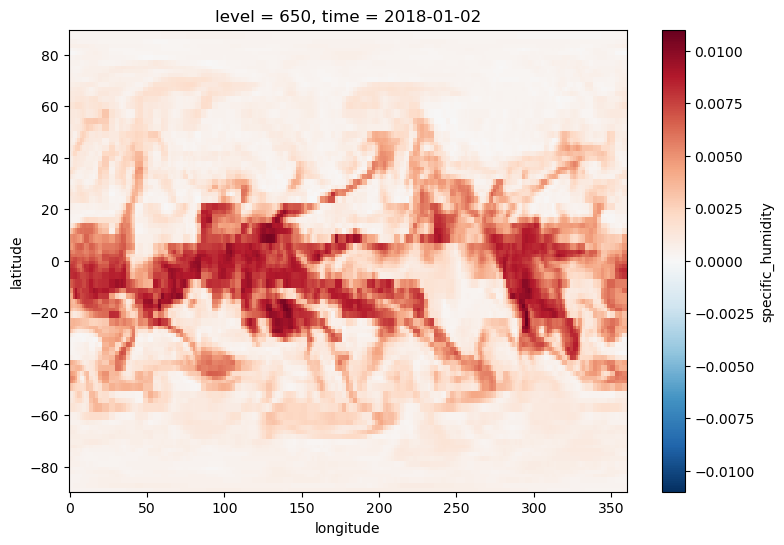

In [15]:
(1.2*data['specific_humidity'].isel(time=0).sel(level=650)).plot(x='longitude', figsize=(9,6))
# (
#     data['specific_humidity'].isel(time=0).sel(level=850)
#     +0.5*data['specific_humidity'].isel(time=1).sel(level=100)
# ).plot(x='longitude', figsize=(9,6))

Text(0.5, 1.0, '')

<Figure size 640x480 with 0 Axes>

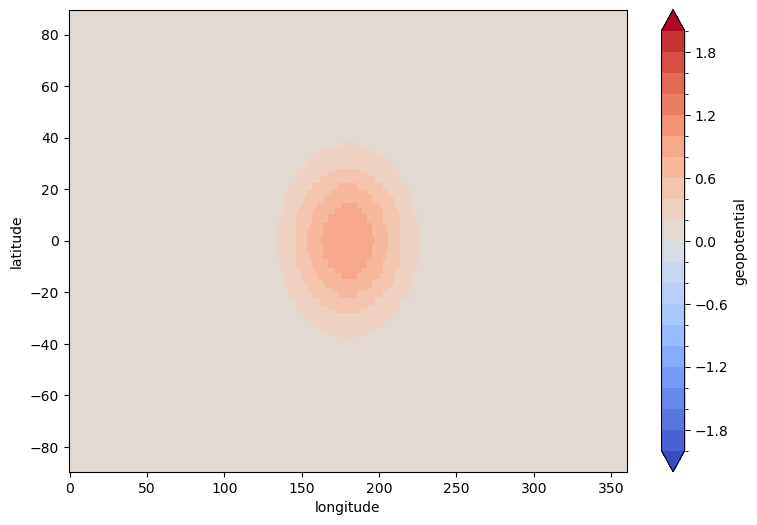

In [160]:
# plt.figure()
# mean_state = xr.zeros_like(data['geopotential'])
# mean_state[:] = 10*np.sin(mean_state.longitude/360)
# mean_state.isel(time=0).sel(level=650).plot(x='longitude', figsize=(9,6), cmap='coolwarm', levels=np.linspace(-10, 10, 21), extend='both')
# plt.title('')

# plt.figure()
# evolved_state = xr.zeros_like(data['geopotential'])
# evolved_state[:] = 10*np.sin((evolved_state.longitude-120)/360)
# evolved_state.isel(time=0).sel(level=650).plot(x='longitude', figsize=(9,6), cmap='coolwarm', levels=np.linspace(-10, 10, 21), extend='both')
# plt.title('')

# plt.figure()
# (evolved_state - mean_state).isel(time=0).sel(level=650).plot(x='longitude', figsize=(9,6), cmap='coolwarm', levels=np.linspace(-4, 1, 21), extend='both')
# plt.title('')

plt.figure()
perturbation = xr.zeros_like(data['geopotential'])
perturbation[:] = 1*np.exp(-100*((perturbation.longitude-180)/360)**2)*np.exp(-150*(perturbation.latitude/360)**2)
perturbation.isel(time=0).sel(level=650).plot(x='longitude', figsize=(9,6), cmap='coolwarm', levels=np.linspace(-2, 2, 21), extend='both')
plt.title('')

# plt.figure()
# (
#     evolved_state
#     + perturbation
#     - (evolved_state - mean_state)
#     - mean_state
# ).isel(time=0).sel(level=650).plot(x='longitude', figsize=(9,6), cmap='coolwarm', levels=np.linspace(-4, 4, 21), extend='both')
# plt.title('')

# plt.figure()
# perturbed_mean_state = xr.zeros_like(data['geopotential'])
# perturbed_mean_state[:] = evolved_state + 2*np.cos((perturbed_mean_state.longitude+80)/360)*np.exp(-100*(perturbed_mean_state.latitude/360)**2) - mean_state
# perturbed_mean_state.isel(time=0).sel(level=650).plot(x='longitude', figsize=(9,6), cmap='coolwarm', levels=np.linspace(-10, 10, 21), extend='both')
# plt.title('')

In [23]:
# era5_path = 'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3'
# full_era5 = xr.open_zarr(
#     era5_path, chunks=None, storage_options=dict(token='anon')
# )

# data_inner_steps = 24
# # sliced_era5 = full_era5.pipe(
# #         xarray_utils.selective_temporal_shift,
# #         variables=full_era5.specific_humidity,
# #         time_shift='24 hours',
# #     ).sel(time=slice(demo_start_time, demo_end_time, data_inner_steps)).compute()

# inner_steps = 24  # save model outputs once every 24 hours
# outer_steps = 30 * 24 // inner_steps  # total of 4 days
# timedelta = np.timedelta64(1, 'h') * inner_steps
# times = (np.arange(outer_steps) * inner_steps)

# sliced_era5 = full_era5.sel(time=slice(demo_start_time, demo_end_time, data_inner_steps))
# sliced_era5['time'] = times

In [24]:
era5_grid = spherical_harmonic.Grid(
    latitude_nodes=full_era5.sizes['latitude'],
    longitude_nodes=full_era5.sizes['longitude'],
    latitude_spacing=xarray_utils.infer_latitude_spacing(full_era5.latitude),
    longitude_offset=xarray_utils.infer_longitude_offset(full_era5.longitude),
)
regridder = horizontal_interpolation.ConservativeRegridder(
    era5_grid, model.data_coords.horizontal, skipna=True
)
eval_era5 = xarray_utils.regrid(sliced_era5, regridder)
eval_era5 = xarray_utils.fill_nan_with_nearest(eval_era5)

In [25]:
eval_era5

<xarray.Dataset> Size: 3GB
Dimensions:                                                          (time: 30,
                                                                      longitude: 256,
                                                                      latitude: 128,
                                                                      level: 37)
Coordinates:
  * level                                                            (level) int64 296B ...
  * time                                                             (time) int64 240B ...
  * longitude                                                        (longitude) float64 2kB ...
  * latitude                                                         (latitude) float64 1kB ...
Data variables: (12/273)
    100m_u_component_of_wind                                         (time, longitude, latitude) float32 4MB ...
    100m_v_component_of_wind                                         (time, longitude, latitude) float32 4MB ...
    10m_u_component_of_neutral_wind                                  (time, longitude, latitude) float32 4MB ...
    10m_u_component_of_wind                                          (time, longitude, latitude) float32 4MB ...
    10m_v_component_of_neutral_wind                                  (time, longitude, latitude) float32 4MB ...
    10m_v_component_of_wind                                          (time, longitude, latitude) float32 4MB ...
    ...                                                               ...
    wave_spectral_directional_width_for_swell                        (time, longitude, latitude) float32 4MB ...
    wave_spectral_directional_width_for_wind_waves                   (time, longitude, latitude) float32 4MB ...
    wave_spectral_kurtosis                                           (time, longitude, latitude) float32 4MB ...
    wave_spectral_peakedness                                         (time, longitude, latitude) float32 4MB ...
    wave_spectral_skewness                                           (time, longitude, latitude) float32 4MB ...
    zero_degree_level                                                (time, longitude, latitude) float32 4MB ...

In [8]:
data = xr.load_dataset("/glade/campaign/univ/uwas0152/2018-01-01_deterministic_cf.nc")
data

<xarray.Dataset> Size: 1GB
Dimensions:                              (longitude: 256, latitude: 128,
                                          level: 37, time: 30)
Coordinates:
  * longitude                            (longitude) float64 2kB 0.0 ... 358.6
  * latitude                             (latitude) float64 1kB -88.93 ... 88.93
  * level                                (level) int32 148B 1 2 3 ... 975 1000
  * time                                 (time) int32 120B 0 24 48 ... 672 696
Data variables:
    u_component_of_wind                  (time, level, longitude, latitude) float32 145MB ...
    specific_cloud_liquid_water_content  (time, level, longitude, latitude) float32 145MB ...
    v_component_of_wind                  (time, level, longitude, latitude) float32 145MB ...
    geopotential                         (time, level, longitude, latitude) float32 145MB ...
    temperature                          (time, level, longitude, latitude) float32 145MB ...
    specific_humidity                    (time, level, longitude, latitude) float32 145MB ...
    specific_cloud_ice_water_content     (time, level, longitude, latitude) float32 145MB ...
    sim_time                             (time) float32 120B 1.795e+05 ... 1....
Attributes:
    longitude_wavenumbers:     128
    total_wavenumbers:         129
    longitude_nodes:           256
    latitude_nodes:            128
    latitude_spacing:          gauss
    longitude_offset:          0.0
    radius:                    1.0
    spherical_harmonics_impl:  RealSphericalHarmonicsWithZeroImag
    spmd_mesh:                 
    centers:                   [   1    2    3    5    7   10   20   30   50 ...
    horizontal_grid_type:      Grid
    vertical_grid_type:        PressureCoordinates

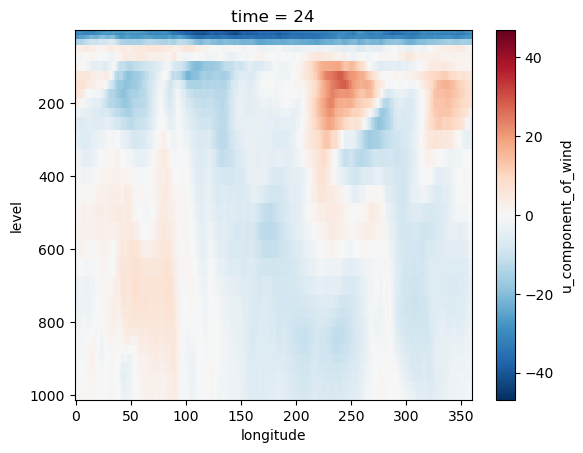

In [18]:
import matplotlib.pyplot as plt
data['u_component_of_wind'].sel(latitude=slice(-10, 10)).mean(dim='latitude').isel(time=1).plot(y='level')
plt.gca().invert_yaxis()
plt.show()

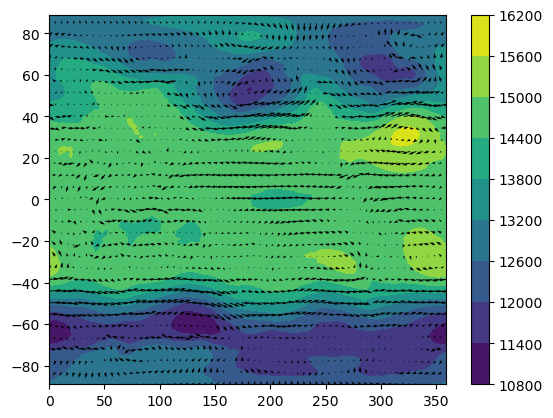

In [23]:
plt.figure()
plt.contourf(
    data['temperature'].longitude,
    data['temperature'].latitude,
    data['geopotential'].sel(level=850).mean(dim='time').T
)
plt.colorbar()

plt.quiver(
    data['temperature'].longitude[::4],
    data['temperature'].latitude[::4],
    data['u_component_of_wind'].sel(level=850).mean(dim='time').T[::4, ::4],
    data['v_component_of_wind'].sel(level=850).mean(dim='time').T[::4, ::4],
)

plt.show()

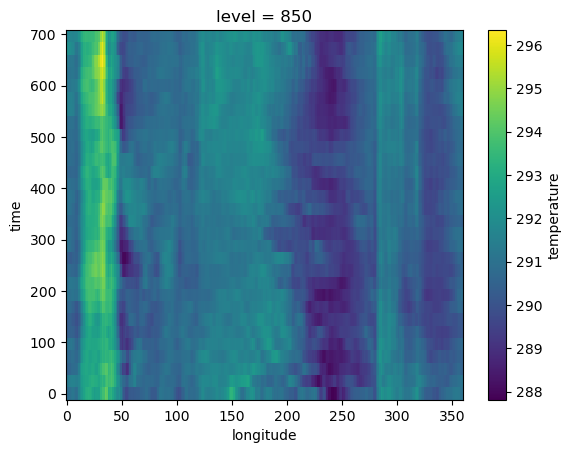

In [24]:
 data['temperature'].sel(latitude=slice(-5,5)).mean(dim='latitude').sel(level=850).plot(x='longitude')

In [26]:
 data['temperature'].sel(latitude=slice(-5,5)).mean(dim='latitude').sel(level=850).time

<xarray.DataArray 'time' (time: 30)> Size: 120B
array([  0,  24,  48,  72,  96, 120, 144, 168, 192, 216, 240, 264, 288, 312,
       336, 360, 384, 408, 432, 456, 480, 504, 528, 552, 576, 600, 624, 648,
       672, 696], dtype=int32)
Coordinates:
    level    int32 4B 850
  * time     (time) int32 120B 0 24 48 72 96 120 144 ... 576 600 624 648 672 696

In [1]:
import xarray as xr
era5_path = 'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3'
full_era5 = xr.open_zarr(
    era5_path, chunks=None, storage_options=dict(token='anon')
)

In [2]:
full_era5

<xarray.Dataset> Size: 4PB
Dimensions:                                                          (
                                                                      time: 1323648,
                                                                      latitude: 721,
                                                                      longitude: 1440,
                                                                      level: 37)
Coordinates:
  * latitude                                                         (latitude) float32 3kB ...
  * level                                                            (level) int64 296B ...
  * longitude                                                        (longitude) float32 6kB ...
  * time                                                             (time) datetime64[ns] 11MB ...
Data variables: (12/273)
    100m_u_component_of_wind                                         (time, latitude, longitude) float32 5TB ...
    100m_v_component_of_wind                                         (time, latitude, longitude) float32 5TB ...
    10m_u_component_of_neutral_wind                                  (time, latitude, longitude) float32 5TB ...
    10m_u_component_of_wind                                          (time, latitude, longitude) float32 5TB ...
    10m_v_component_of_neutral_wind                                  (time, latitude, longitude) float32 5TB ...
    10m_v_component_of_wind                                          (time, latitude, longitude) float32 5TB ...
    ...                                                               ...
    wave_spectral_directional_width_for_swell                        (time, latitude, longitude) float32 5TB ...
    wave_spectral_directional_width_for_wind_waves                   (time, latitude, longitude) float32 5TB ...
    wave_spectral_kurtosis                                           (time, latitude, longitude) float32 5TB ...
    wave_spectral_peakedness                                         (time, latitude, longitude) float32 5TB ...
    wave_spectral_skewness                                           (time, latitude, longitude) float32 5TB ...
    zero_degree_level                                                (time, latitude, longitude) float32 5TB ...
Attributes:
    last_updated:           2025-06-30 01:47:00.511182+00:00
    valid_time_start:       1940-01-01
    valid_time_stop:        2025-02-28
    valid_time_stop_era5t:  2025-06-24

In [46]:
demo_start_time = '2018-01-01'
demo_end_time = '2018-01-30'
data_inner_steps = 24
# sliced_era5 = full_era5.pipe(
#         xarray_utils.selective_temporal_shift,
#         variables=full_era5.specific_humidity,
#         time_shift='24 hours',
#     ).sel(time=slice(demo_start_time, demo_end_time, data_inner_steps)).compute()

import numpy as np
inner_steps = 24  # save model outputs once every 24 hours
outer_steps = 30 * 24 // inner_steps  # total of 4 days
timedelta = np.timedelta64(1, 'h') * inner_steps
times = (np.arange(outer_steps) * inner_steps)

sliced_era5 = full_era5.sel(time=slice(demo_start_time, demo_end_time, data_inner_steps))
sliced_era5['time'] = times

In [47]:
sliced_era5

<xarray.Dataset> Size: 83GB
Dimensions:                                                          (time: 30,
                                                                      latitude: 721,
                                                                      longitude: 1440,
                                                                      level: 37)
Coordinates:
  * latitude                                                         (latitude) float32 3kB ...
  * level                                                            (level) int64 296B ...
  * longitude                                                        (longitude) float32 6kB ...
  * time                                                             (time) int64 240B ...
Data variables: (12/273)
    100m_u_component_of_wind                                         (time, latitude, longitude) float32 125MB ...
    100m_v_component_of_wind                                         (time, latitude, longitude) float32 125MB ...
    10m_u_component_of_neutral_wind                                  (time, latitude, longitude) float32 125MB ...
    10m_u_component_of_wind                                          (time, latitude, longitude) float32 125MB ...
    10m_v_component_of_neutral_wind                                  (time, latitude, longitude) float32 125MB ...
    10m_v_component_of_wind                                          (time, latitude, longitude) float32 125MB ...
    ...                                                               ...
    wave_spectral_directional_width_for_swell                        (time, latitude, longitude) float32 125MB ...
    wave_spectral_directional_width_for_wind_waves                   (time, latitude, longitude) float32 125MB ...
    wave_spectral_kurtosis                                           (time, latitude, longitude) float32 125MB ...
    wave_spectral_peakedness                                         (time, latitude, longitude) float32 125MB ...
    wave_spectral_skewness                                           (time, latitude, longitude) float32 125MB ...
    zero_degree_level                                                (time, latitude, longitude) float32 125MB ...
Attributes:
    last_updated:           2025-06-30 01:47:00.511182+00:00
    valid_time_start:       1940-01-01
    valid_time_stop:        2025-02-28
    valid_time_stop_era5t:  2025-06-24

In [50]:
sliced_data = data.sel(level=850)
sliced_data['time'] = times

In [12]:
# data
eval_era5

<xarray.Dataset> Size: 658MB
Dimensions:                                                          (time: 30,
                                                                      longitude: 128,
                                                                      latitude: 64,
                                                                      level: 37)
Coordinates:
  * level                                                            (level) int64 296B ...
  * time                                                             (time) int64 240B ...
  * longitude                                                        (longitude) float64 1kB ...
  * latitude                                                         (latitude) float64 512B ...
Data variables: (12/273)
    100m_u_component_of_wind                                         (time, longitude, latitude) float32 983kB ...
    100m_v_component_of_wind                                         (time, longitude, latitude) float32 983kB ...
    10m_u_component_of_neutral_wind                                  (time, longitude, latitude) float32 983kB ...
    10m_u_component_of_wind                                          (time, longitude, latitude) float32 983kB ...
    10m_v_component_of_neutral_wind                                  (time, longitude, latitude) float32 983kB ...
    10m_v_component_of_wind                                          (time, longitude, latitude) float32 983kB ...
    ...                                                               ...
    wave_spectral_directional_width_for_swell                        (time, longitude, latitude) float32 983kB ...
    wave_spectral_directional_width_for_wind_waves                   (time, longitude, latitude) float32 983kB ...
    wave_spectral_kurtosis                                           (time, longitude, latitude) float32 983kB ...
    wave_spectral_peakedness                                         (time, longitude, latitude) float32 983kB ...
    wave_spectral_skewness                                           (time, longitude, latitude) float32 983kB ...
    zero_degree_level                                                (time, longitude, latitude) float32 983kB ...

In [81]:
era5_grid = spherical_harmonic.Grid(
    latitude_nodes=full_era5.sizes['latitude'],
    longitude_nodes=full_era5.sizes['longitude'],
    latitude_spacing=xarray_utils.infer_latitude_spacing(full_era5.latitude),
    longitude_offset=xarray_utils.infer_longitude_offset(full_era5.longitude),
)
regridder = horizontal_interpolation.ConservativeRegridder(
    era5_grid, model.data_coords.horizontal, skipna=True
)
eval_era5 = xarray_utils.regrid(sliced_era5, regridder)
eval_era5 = xarray_utils.fill_nan_with_nearest(eval_era5)

AttributeError: 'Dataset' object has no attribute 'data_coords'

In [26]:
combined_ds = xr.concat([eval_era5.transpose('time','latitude','longitude','level'), data.transpose('time','latitude','longitude','level')], 'model')
combined_ds.coords['model'] = ['ERA5', 'NeuralGCM']

In [31]:
combined_ds.longitude

<xarray.DataArray 'longitude' (longitude: 325)> Size: 3kB
array([  0.     ,   1.40625,   2.8125 , ..., 357.1875 , 357.1875 , 358.59375])
Coordinates:
  * longitude  (longitude) float64 3kB 0.0 1.406 2.812 ... 357.2 357.2 358.6

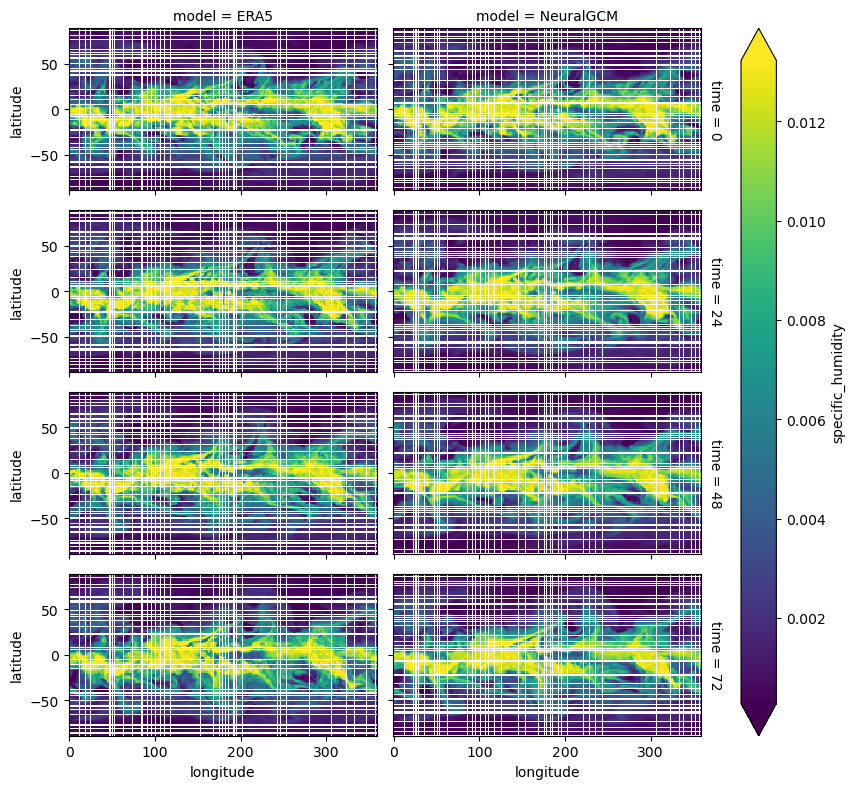

In [27]:
combined_ds.specific_humidity.isel(time=slice(0,4)).sel(level=850).plot(
    x='longitude', y='latitude', row='time', col='model', robust=True, aspect=2, size=2
);

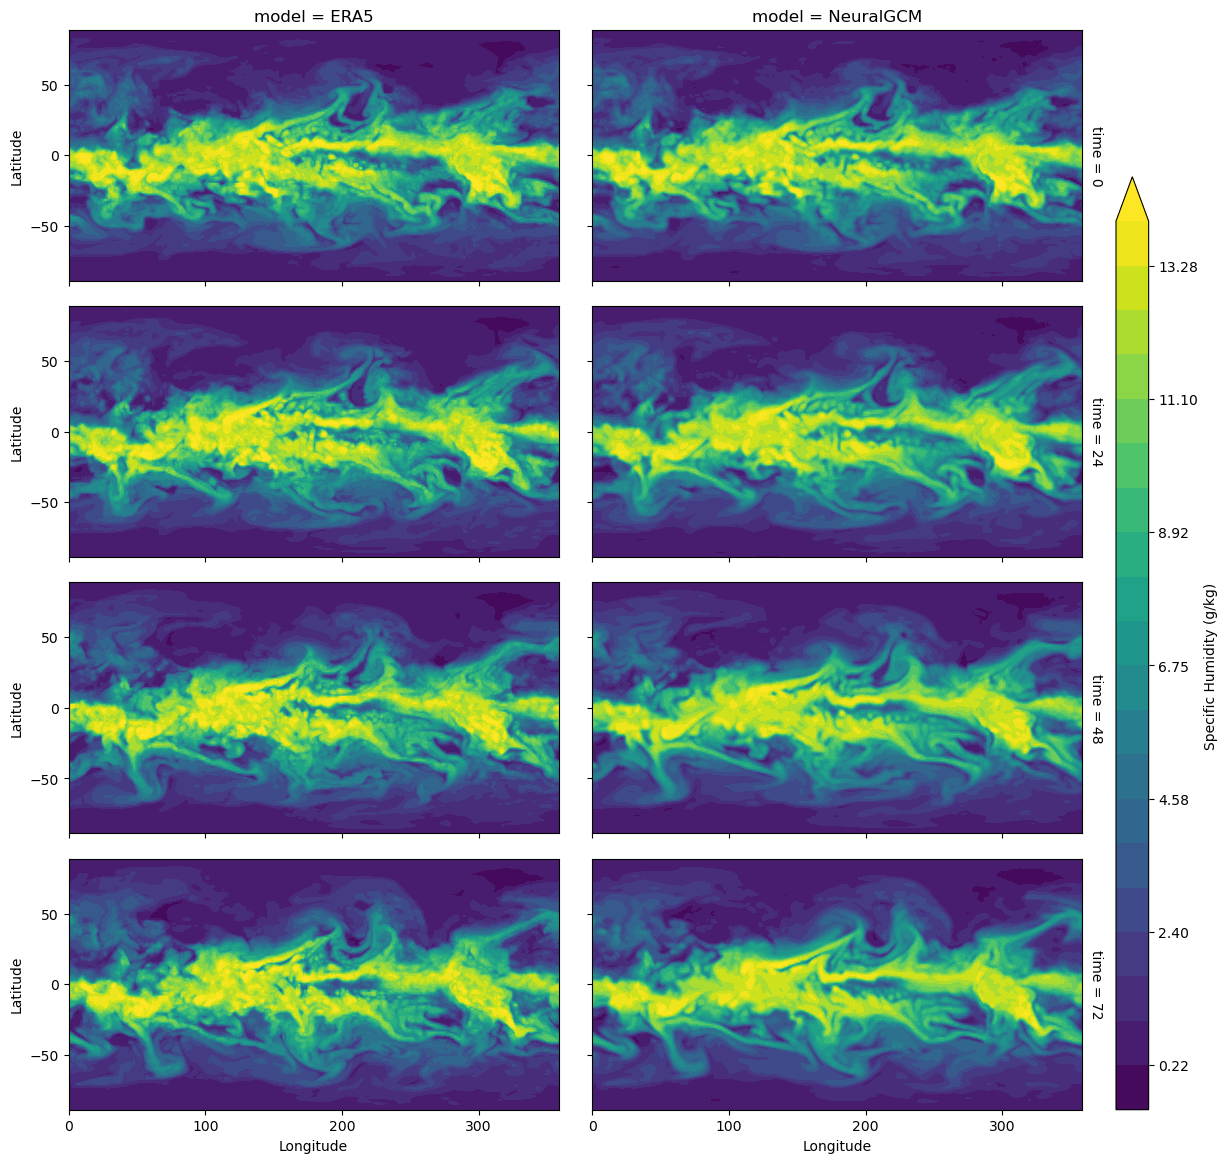

In [73]:
from matplotlib import colors as mcolors
from matplotlib import ticker as mticker
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 12))
gs = GridSpec(4, 3, figure=fig, width_ratios = [30, 30, 2])
gs.update(top=0.95, bottom=0.05, left=0.05, right=0.95, hspace=0.1, wspace=0.1)

left_ax = []
left_ax.append(fig.add_subplot(gs[0, 0]))
left_ax.append(fig.add_subplot(gs[1, 0]))
left_ax.append(fig.add_subplot(gs[2, 0]))
left_ax.append(fig.add_subplot(gs[3, 0]))

right_ax = []
right_ax.append(fig.add_subplot(gs[0, 1]))
right_ax.append(fig.add_subplot(gs[1, 1]))
right_ax.append(fig.add_subplot(gs[2, 1]))
right_ax.append(fig.add_subplot(gs[3, 1]))

cbar_axis = fig.add_subplot(gs[:, -1])

levels = np.linspace(-0.5, 14, 21)


left_ax[0].set_title('model = ERA5')
right_ax[0].set_title('model = NeuralGCM')
for index, time in enumerate(range(0, 4, 1)):
    left_ax[index].contourf(
        eval_era5.longitude,
        eval_era5.latitude,
        1000*eval_era5.specific_humidity.sel(time=times[time]).sel(level=850).T,
        levels=levels,
        extend='max',
        cmap='viridis'
    )
    left_ax[index].set_ylabel('Latitude')
    left_ax[index].set_yticks([-50, 0, 50])
    left_ax[index].set_xticks([0, 100, 200, 300], labels=[])
    im = right_ax[index].contourf(
        data.longitude,
        data.latitude,
        1000*data.specific_humidity.sel(time=times[time]).sel(level=850).T,
        levels=levels,
        extend='max',
        cmap='viridis'
    )
    right_ax[index].yaxis.set_label_position("right")
    right_ax[index].set_yticks([-50, 0, 50], labels=[])
    right_ax[index].set_xticks([0, 100, 200, 300], labels=[])
    right_ax[index].set_ylabel(f"time = {times[time]}", rotation=270, labelpad=15)
    cbar = fig.colorbar(im, cax=cbar_axis)
    cbar.set_label('Specific Humidity (g/kg)')

left_ax[3].set_xlabel('Longitude')
right_ax[3].set_xlabel('Longitude')
left_ax[3].set_xticks([0, 100, 200, 300], labels=[0, 100, 200, 300])
right_ax[3].set_xticks([0, 100, 200, 300], labels=[0, 100, 200, 300])

plt.show()

In [80]:
# # print(data.dims)
# # print(eval_era5.dims)

# test = data.isel(time=0)
# test

model.inputs_from_xarray(eval_era5.isel(time=0))

# data

UFuncTypeError: ufunc 'subtract' cannot use operands with types dtype('int64') and dtype('<M8[h]')

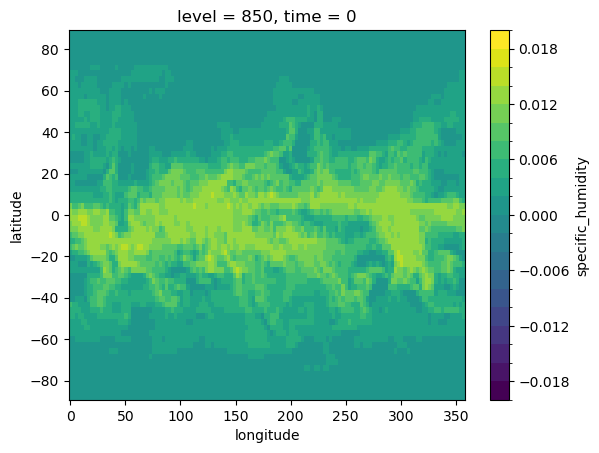

In [18]:
eval_era5.specific_humidity.isel(time=0).sel(level=850).plot(x='longitude', y='latitude', cmap='viridis', levels=np.linspace(-0.02, 0.02, 21))